<a href="https://colab.research.google.com/github/abidahnisaa/Project_Breast_Cancer_Poster_Presentation_UNS/blob/main/6.%20Machine_Learning_Breast_Cancer_optimatization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# BREAST CANCER BINDING AFFINITY — ML CLASSIFICATION PIPELINE (v2)
# ================================================================
# Pipeline ini melatih, men-tuning, dan membandingkan model klasifikasi
# (Logistic Regression, SVM, KNN, Decision Tree, Random Forest,
# Gradient Boosting) terhadap 3 jenis fingerprint molekuler
# (MACCS, Morgan, PubChem) untuk memprediksi kategori binding
# affinity (High/Low) berdasarkan threshold tertentu.
#
# DATASET INI IMBALANCED -> seluruh pipeline menangani hal ini secara
# eksplisit: class_weight, scoring yang robust terhadap imbalance,
# COMPOSITE RANK untuk seleksi model (menggabungkan SEMUA metrik —
# F1, AUC, Recall, Sensitivity, Specificity, MCC, dll — bukan hanya
# satu metrik tunggal), dan threshold tuning di akhir.
#
# Struktur pipeline (12 TAHAP):
#   TAHAP 1  — Import & Setup Lingkungan
#   TAHAP 2  — Parameter & Konfigurasi
#   TAHAP 3  — Fungsi Bantuan (Helper Functions)
#   TAHAP 4  — Load Data Fingerprint
#   TAHAP 5  — Persiapan Dataset, Label, & Cek Imbalance
#   TAHAP 6  — Definisi Model & Grid Hyperparameter
#   TAHAP 7  — Training Baseline (CV + Test) per Model
#   TAHAP 8  — Rekap Hasil & Composite Ranking Model Baseline
#   TAHAP 9  — Hyperparameter Tuning untuk Model Terbaik per Fingerprint
#   TAHAP 10 — Visualisasi Perbandingan Menyeluruh
#   TAHAP 11 — Analisis Akhir: Feature Importance, Error Analysis,
#              Threshold Tuning, & Penyimpanan Model Final
#   TAHAP 12 — UJI STATISTIK: Model mana & Fingerprint mana yang
#              SECARA SIGNIFIKAN lebih baik (bukan hanya beda angka)
#   TAHAP 13 — VALIDITAS KESELURUHAN PROSES MODELING:
#              data leakage check, stabilitas multi-seed, overfitting
#              gap, learning curve, variance antar fold, dummy baseline
#   TAHAP 14 — LAPORAN INTERPRETASI OTOMATIS: merangkai SELURUH narasi
#              interpretasi dari Tahap 5-13 menjadi 1 dokumen (.md)
# ================================================================


In [ ]:

# ================================================================
# TAHAP 1 — IMPORT & SETUP LINGKUNGAN
# ================================================================
# Tujuan: memasang library, mengimpor seluruh modul, mount Drive.

!pip install openpyxl scikit-learn joblib -q

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import drive

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    cross_val_predict,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    GridSearchCV,
    learning_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    matthews_corrcoef,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from scipy.stats import friedmanchisquare, kruskal, mannwhitneyu, rankdata, studentized_range
from itertools import combinations

warnings.filterwarnings("ignore")

drive.mount('/content/drive')

# ----------------------------------------------------------------
# SKEMA WARNA PROJECT (dipakai konsisten di SELURUH grafik pipeline)
# ----------------------------------------------------------------
project_colors = {
    "bg": "#FFFFFF",
    "text": "#18162D",

    "tumor": "#C2185B",
    "normal": "#329325",

    "up": "#C2185B",
    "down": "#1F6FB2",
    "ns": "#B8B0BD",

    "up_dark": "#8B0A50",
    "down_dark": "#0D4F8B",
    "ns_dark": "#5A5360",

    "strip": "#E7C6D6",
    "grid": "#E5E5E5",

    "gold": "#D4A017",
    "outlier": "#FF8C42"
}

# Siklus warna kategorikal untuk grafik dengan banyak entitas (>2), misal
# perbandingan 3 fingerprint atau 6 model dalam satu boxplot/line chart.
CATEGORICAL_PALETTE = [
    project_colors["up"],
    project_colors["down"],
    project_colors["gold"],
    project_colors["normal"],
    project_colors["ns_dark"],
    project_colors["outlier"],
]

# Colormap diverging custom (rendah -> netral -> tinggi) untuk heatmap,
# memakai warna brand sebagai pengganti "RdYlGn" bawaan matplotlib.
from matplotlib.colors import LinearSegmentedColormap
project_diverging_cmap = LinearSegmentedColormap.from_list(
    "project_diverging",
    [project_colors["down_dark"], project_colors["strip"], project_colors["up_dark"]]
)
# Colormap sekuensial (terang -> gelap) untuk confusion matrix.
project_cm_baseline_cmap = LinearSegmentedColormap.from_list(
    "project_cm_baseline", [project_colors["bg"], project_colors["up_dark"]]
)
project_cm_tuned_cmap = LinearSegmentedColormap.from_list(
    "project_cm_tuned", [project_colors["bg"], project_colors["down_dark"]]
)

# Terapkan skema warna ini sebagai default global matplotlib, supaya
# SETIAP plt.figure()/plt.plot() di seluruh pipeline otomatis konsisten
# tanpa perlu mengulang argumen warna di setiap baris.
plt.rcParams.update({
    "figure.facecolor": project_colors["bg"],
    "axes.facecolor": project_colors["bg"],
    "axes.edgecolor": project_colors["text"],
    "axes.labelcolor": project_colors["text"],
    "axes.titlecolor": project_colors["text"],
    "axes.grid": True,
    "grid.color": project_colors["grid"],
    "grid.alpha": 1.0,
    "text.color": project_colors["text"],
    "xtick.color": project_colors["text"],
    "ytick.color": project_colors["text"],
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL_PALETTE),
    "legend.frameon": False,
    "savefig.facecolor": project_colors["bg"],
})
sns.set_style("white")

print("TAHAP 1 selesai: Library siap, Google Drive ter-mount, skema warna project diterapkan.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TAHAP 1 selesai: Library siap, Google Drive ter-mount, skema warna project diterapkan.


In [ ]:

# ================================================================
# TAHAP 2 — PARAMETER & KONFIGURASI
# ================================================================
# Tujuan: satu tempat untuk semua konstanta, path, dan saklar opsi
# supaya seluruh perilaku pipeline mudah disesuaikan.

AFFINITY_COL = "best_affinity_kcal_mol"   # kolom nilai binding affinity
LABEL_COL = "Label"                       # kolom label hasil binarisasi

BINDING_THRESHOLD = -9.0   # affinity <= threshold -> High Binding (1)

TEST_SIZE = 0.20
CV_FOLDS = 5
RANDOM_STATE = 42

# Dataset diketahui IMBALANCED -> seleksi model TIDAK memakai accuracy
# sendirian (accuracy menyesatkan saat kelas timpang: model yang asal
# menebak kelas mayoritas tetap bisa terlihat "akurat"). IMBALANCE_RATIO_
# WARN_THRESHOLD dipakai untuk auto-flag tingkat ketidakseimbangan di Tahap 5.
IMBALANCE_RATIO_WARN_THRESHOLD = 1.5   # rasio kelas mayoritas:minoritas

# Metrik cross-validation pada data train.
SCORING = {
    "accuracy": "accuracy",
    "f1_weighted": "f1_weighted",
    "roc_auc": "roc_auc",
    "recall_weighted": "recall_weighted",
    "balanced_accuracy": "balanced_accuracy"
}

# ----------------------------------------------------------------
# STRATEGI SELEKSI MODEL: COMPOSITE RANK (bukan satu metrik tunggal)
# ----------------------------------------------------------------
# Setiap metrik di bawah ini dirangking secara TERPISAH (rank 1 = terbaik
# untuk metrik tersebut), lalu seluruh rank digabung (dijumlah) menjadi
# satu "Composite_Rank". Model dengan Composite_Rank terkecil = model
# yang paling konsisten unggul di SELURUH metrik, bukan hanya menang
# di satu metrik tapi lemah di metrik lain. "Test Accuracy" SENGAJA
# tidak dimasukkan ke dalam composite rank karena bisa menyesatkan pada
# data imbalanced; tetap dihitung & ditampilkan, tapi hanya sebagai
# referensi, bukan komponen ranking.
COMPOSITE_RANK_METRICS = [
    "CV F1 Score",
    "CV AUC",
    "CV Recall",
    "CV Balanced Accuracy",
    "Test F1 Score",
    "Test Precision (Weighted)",
    "Test AUC",
    "Test Recall (Weighted)",
    "Sensitivity",
    "Specificity",
    "MCC"
]

cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# --- Konfigurasi untuk UJI STATISTIK (Tahap 12) ---
# Repeated Stratified K-Fold menghasilkan N_REPEATS x CV_FOLDS skor
# per model/fingerprint (mis. 5x5=25), dipakai sebagai sampel untuk
# uji signifikansi -- bukan cuma 1 angka titik dari single split.
N_REPEATS_STAT_TEST = 5
ALPHA = 0.05   # ambang signifikansi (p-value) untuk semua uji statistik

repeated_cv_strategy = RepeatedStratifiedKFold(
    n_splits=CV_FOLDS,
    n_repeats=N_REPEATS_STAT_TEST,
    random_state=RANDOM_STATE
)

# Metrik yang dipakai sebagai dasar uji statistik. MCC dipilih karena
# tahan terhadap imbalance dan merupakan ringkasan tunggal performa
# klasifikasi biner (mengandung info dari ke-4 sel confusion matrix).
STAT_TEST_METRIC = "matthews_corrcoef"

# --- Konfigurasi untuk VALIDITAS PROSES (Tahap 13) ---
N_SEEDS_STABILITY_CHECK = 10        # jumlah random_state berbeda untuk uji stabilitas split
SEEDS_TO_TEST = list(range(N_SEEDS_STABILITY_CHECK))
STABILITY_GAP_WARN_THRESHOLD = 0.15  # selisih MCC antar seed yang dianggap "tidak stabil"
OVERFIT_GAP_WARN_THRESHOLD = 0.15    # selisih skor Train vs CV yang dianggap indikasi overfitting
LEARNING_CURVE_TRAIN_SIZES = np.linspace(0.2, 1.0, 6)  # 20%, 36%, ..., 100% data train

# Lokasi file fingerprint sumber (input)
FINGERPRINT_FILES = {
    "MACCS": "/content/drive/MyDrive/Breast Cancer Model/Fingerprint/hasil_fingerprint_MACCS.xlsx",
    "Morgan": "/content/drive/MyDrive/Breast Cancer Model/Fingerprint/hasil_fingerprint_morgan.xlsx",
    "PubChem": "/content/drive/MyDrive/Breast Cancer Model/Fingerprint/hasil_fingerprint_pubchem.xlsx"
}

# Struktur folder output
OUTPUT_DIR = "/content/drive/MyDrive/Breast Cancer Model/ML_Result6"
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Urutan model untuk konsistensi tampilan grafik
MODEL_ORDER = [
    "LogisticRegression",
    "SVM",
    "KNN",
    "DecisionTree",
    "RandomForest",
    "GradientBoosting"
]

# Saklar: nyalakan/matikan hyperparameter tuning (Tahap 9) jika perlu
# mempercepat eksekusi saat eksplorasi awal.
RUN_HYPERPARAMETER_TUNING = True

print("TAHAP 2 selesai: Parameter & folder output siap.")
print(f"Strategi seleksi model: Composite Rank dari {len(COMPOSITE_RANK_METRICS)} metrik "
      f"(Accuracy dikecualikan dari ranking karena data imbalanced).")


TAHAP 2 selesai: Parameter & folder output siap.
Strategi seleksi model: Composite Rank dari 11 metrik (Accuracy dikecualikan dari ranking karena data imbalanced).


In [ ]:
# ----------------------------------------------------------------
# INFRASTRUKTUR INTERPRETASI OTOMATIS (dipakai di seluruh tahap)
# ----------------------------------------------------------------
# Setiap hasil penting (tabel, uji statistik, grafik) akan diberi
# narasi otomatis yang menerjemahkan ANGKA menjadi ARTI/MAKNA --
# dibandingkan dengan ambang batas yang relevan, lalu diberi
# rekomendasi konkret. Seluruh narasi dikumpulkan di sini dan akan
# dirangkai jadi 1 laporan akhir (.md) di Tahap 14.
interpretation_log = []   # list of dict: {"tahap": str, "judul": str, "narasi": str}

def log_interpretation(tahap, judul, narasi, print_now=True):
    """Mencatat narasi interpretasi untuk 1 hasil, sekaligus mencetaknya
    ke console (jika print_now=True) supaya muncul tepat setelah tabel/
    grafik terkait, dan menyimpannya untuk laporan akhir Tahap 14."""
    interpretation_log.append({"Tahap": tahap, "Judul": judul, "Narasi": narasi})
    if print_now:
        print(f"\n>> INTERPRETASI [{judul}]")
        print(narasi)


In [ ]:
# ================================================================
# TAHAP 3 — FUNGSI BANTUAN (HELPER FUNCTIONS)
# ================================================================
# Tujuan: fungsi reusable untuk I/O, pembersihan kolom, ekstraksi
# fitur, metrik aman, dan diagnostik imbalance.

def read_table(path):
    """Membaca file .xlsx/.xls/.csv menjadi DataFrame."""
    if path.endswith(".xlsx") or path.endswith(".xls"):
        return pd.read_excel(path)
    elif path.endswith(".csv"):
        return pd.read_csv(path)
    else:
        raise ValueError(f"Format file tidak dikenali: {path}")


def clean_column_names(df):
    """Merapikan nama kolom: hapus spasi/simbol agar konsisten."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace("/", "_")
        .str.replace(".", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df


def load_fingerprint_data(fingerprint_files):
    """Memuat seluruh file fingerprint menjadi dict {nama: DataFrame}."""
    loaded = {}
    for fp_name, path in fingerprint_files.items():
        df = read_table(path)
        df = clean_column_names(df)
        loaded[fp_name] = df
        print(fp_name, df.shape)
    return loaded


def get_bit_columns(df):
    """Mengambil semua kolom fitur fingerprint (mengandung kata 'bit')."""
    return [col for col in df.columns if "bit" in col.lower()]


def safe_roc_auc_score(y_true, y_score):
    """ROC-AUC yang aman terhadap kasus y_score None atau label tunggal."""
    if y_score is None:
        return np.nan
    if len(set(y_true)) <= 1:
        return np.nan
    return roc_auc_score(y_true, y_score)


def compute_specificity_sensitivity(y_true, y_pred):
    """Menghitung confusion matrix, specificity, dan sensitivity."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return cm, specificity, sensitivity


def diagnose_imbalance(y, label="Dataset"):
    """Menghitung rasio kelas dan memberi peringatan jika imbalanced."""
    counts = y.value_counts()
    majority = counts.max()
    minority = counts.min()
    ratio = majority / minority if minority > 0 else np.inf

    status = "IMBALANCED" if ratio >= IMBALANCE_RATIO_WARN_THRESHOLD else "RELATIF SEIMBANG"

    print(f"[{label}] Distribusi kelas: {dict(counts)} | Rasio mayoritas:minoritas = {ratio:.2f}:1 -> {status}")

    return {
        "label": label,
        "class_0": int(counts.get(0, 0)),
        "class_1": int(counts.get(1, 0)),
        "imbalance_ratio": ratio,
        "status": status
    }


def nemenyi_posthoc_test(rank_matrix):
    """
    Uji post-hoc Nemenyi (manual, tanpa library eksternal) untuk
    menentukan PASANGAN model mana yang berbeda signifikan setelah
    Friedman test mendeteksi ada perbedaan keseluruhan.

    rank_matrix: array (n_folds x n_models) berisi RANK (bukan skor
                 mentah) tiap model pada tiap fold. Dihasilkan dari
                 rankdata per baris (per fold).

    Return: DataFrame matriks p-value antar pasangan model (indeks &
            kolom = nama model yang ditaruh sebagai posisi 0..n-1).
    """
    n_folds, n_models = rank_matrix.shape
    avg_ranks = rank_matrix.mean(axis=0)

    # Critical Difference (CD) Nemenyi:
    # CD = q_alpha * sqrt(n_models*(n_models+1) / (6*n_folds))
    # q_alpha didekati lewat studentized range distribution.
    q_alpha = studentized_range.ppf(1 - ALPHA, n_models, np.inf) / np.sqrt(2)

    se = np.sqrt(n_models * (n_models + 1) / (6.0 * n_folds))
    cd = q_alpha * se

    pval_matrix = np.ones((n_models, n_models))
    for i in range(n_models):
        for j in range(n_models):
            if i == j:
                continue
            diff = abs(avg_ranks[i] - avg_ranks[j])
            # Konversi diff rank ke z-score lalu p-value dua-arah
            z = diff / se
            from scipy.stats import norm
            p = 2 * (1 - norm.cdf(z))
            pval_matrix[i, j] = p

    return pval_matrix, avg_ranks, cd


def cliffs_delta(x, y):
    """
    Cliff's Delta: ukuran effect size non-parametrik untuk 2 sampel
    independen (dipakai untuk perbandingan antar-fingerprint, karena
    sampelnya tidak berpasangan 1:1).
    Interpretasi |delta|: <0.147 negligible, <0.33 small,
    <0.474 medium, >=0.474 large (Romano et al., 2006).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n_x, n_y = len(x), len(y)
    more = sum(xi > yi for xi in x for yi in y)
    less = sum(xi < yi for xi in x for yi in y)
    delta = (more - less) / (n_x * n_y)

    abs_d = abs(delta)
    if abs_d < 0.147:
        magnitude = "Negligible"
    elif abs_d < 0.33:
        magnitude = "Small"
    elif abs_d < 0.474:
        magnitude = "Medium"
    else:
        magnitude = "Large"

    return delta, magnitude


def rank_biserial_from_wilcoxon(x, y):
    """
    Rank-biserial correlation sebagai effect size untuk perbandingan
    berpasangan (model A vs model B pada fold yang sama).
    r = (n_plus - n_minus) / n_total, dari selisih berpasangan.
    """
    diffs = np.asarray(x) - np.asarray(y)
    diffs_nonzero = diffs[diffs != 0]
    if len(diffs_nonzero) == 0:
        return 0.0, "Negligible"
    n_plus = np.sum(diffs_nonzero > 0)
    n_minus = np.sum(diffs_nonzero < 0)
    r = (n_plus - n_minus) / len(diffs_nonzero)

    abs_r = abs(r)
    if abs_r < 0.1:
        magnitude = "Negligible"
    elif abs_r < 0.3:
        magnitude = "Small"
    elif abs_r < 0.5:
        magnitude = "Medium"
    else:
        magnitude = "Large"

    return r, magnitude


def style_boxplot(bp, palette=None, outlier_color=None):
    """Mewarnai elemen boxplot matplotlib (box, median, whiskers, outliers)
    sesuai skema warna project. `palette` = list warna per box (siklus
    CATEGORICAL_PALETTE jika None); outlier_color default project_colors['outlier']."""
    palette = palette or CATEGORICAL_PALETTE
    outlier_color = outlier_color or project_colors["outlier"]

    for i, box in enumerate(bp["boxes"]):
        color = palette[i % len(palette)]
        box.set(facecolor=color, alpha=0.35, edgecolor=color, linewidth=1.5)
    for median in bp["medians"]:
        median.set(color=project_colors["text"], linewidth=1.5)
    for whisker in bp["whiskers"]:
        whisker.set(color=project_colors["ns_dark"], linewidth=1.0)
    for cap in bp["caps"]:
        cap.set(color=project_colors["ns_dark"], linewidth=1.0)
    for flier in bp["fliers"]:
        flier.set(marker="o", markerfacecolor=outlier_color, markeredgecolor=outlier_color, markersize=5, alpha=0.7)


def plot_roc_curve_styled(y_true, y_score, title, save_path, line_color=None, chance_color=None):
    """Wrapper RocCurveDisplay.from_predictions yang aman lintas versi sklearn.
    Parameter untuk mewarnai garis ROC berbeda antar versi sklearn:
      - versi BARU (>=1.7-an): pakai curve_kwargs={"color": ...}
      - versi LAMA: pakai color=... langsung
    Mendeteksi versi yang benar-benar didukung lewat inspect.signature
    (BUKAN trial-and-error try/except, karena pada versi lama parameter
    yang tidak dikenal diteruskan ke Line2D.set() dan memicu AttributeError
    yang sulit ditangkap dengan rapi, serta menyisakan figure kosong)."""
    import inspect

    line_color = line_color or project_colors["up"]
    chance_color = chance_color or project_colors["ns"]

    supports_curve_kwargs = "curve_kwargs" in inspect.signature(RocCurveDisplay.from_predictions).parameters

    plt.figure(figsize=(5, 5))
    if supports_curve_kwargs:
        RocCurveDisplay.from_predictions(
            y_true, y_score,
            curve_kwargs={"color": line_color},
            chance_level_kw={"color": chance_color, "linestyle": "--"},
            plot_chance_level=True
        )
    else:
        RocCurveDisplay.from_predictions(
            y_true, y_score,
            color=line_color,
            chance_level_kw={"color": chance_color, "linestyle": "--"},
            plot_chance_level=True
        )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")


print("TAHAP 3 selesai: Helper functions siap dipakai.")



TAHAP 3 selesai: Helper functions siap dipakai.


In [ ]:
# ----------------------------------------------------------------
# FUNGSI INTERPRETASI OTOMATIS PER JENIS HASIL
# ----------------------------------------------------------------
# Masing-masing fungsi menerima data hasil (DataFrame/angka) dan
# mengembalikan STRING narasi yang menjelaskan ARTI hasil tersebut --
# bukan cuma mengulang angka, tapi membandingkan dengan ambang batas
# yang relevan dan memberi rekomendasi. Dipanggil lewat log_interpretation().

def interpret_dataset_summary(dataset_summary_df, imbalance_df):
    lines = []
    for _, row in dataset_summary_df.iterrows():
        fp = row["Fingerprint"]
        imb_row = imbalance_df[imbalance_df["label"] == fp].iloc[0]
        lines.append(
            f"- **{fp}**: {row['N_Samples']} sampel, {row['N_Features_Used']} fitur dipakai "
            f"(dari {row['N_Features_Raw']} fitur mentah -> "
            f"{row['N_Features_Raw'] - row['N_Features_Used']} fitur konstan dibuang). "
            f"Distribusi label: {row['Class_0_LowBinding']} Low Binding vs {row['Class_1_HighBinding']} "
            f"High Binding (rasio {imb_row['imbalance_ratio']:.2f}:1, {imb_row['status']})."
        )
    overall = (
        "Ketiga fingerprint memiliki jumlah sampel yang SAMA (berasal dari senyawa yang sama), "
        "namun jumlah fitur berbeda karena masing-masing skema fingerprint punya representasi bit "
        "yang berbeda. Rasio imbalance yang konsisten di atas ambang "
        f"({IMBALANCE_RATIO_WARN_THRESHOLD}:1) berarti SELURUH analisis berikutnya (composite rank, "
        "uji statistik, validitas) memang seharusnya menghindari accuracy sebagai metrik utama -- "
        "keputusan ini sudah dipegang konsisten sejak Tahap 2."
    )
    return "\n".join(lines) + "\n\n" + overall


def interpret_composite_ranking(best_per_fp_df):
    lines = []
    for _, row in best_per_fp_df.iterrows():
        lines.append(
            f"- **{row['Fingerprint']}**: model terbaik = **{row['Model']}** "
            f"(Composite_Rank={row['Composite_Rank']:.0f}, MCC={row['MCC']:.4f}, "
            f"F1={row['Test F1 Score']:.4f}, AUC={row['Test AUC']:.4f}). "
        )
        if row["MCC"] < 0.2:
            lines.append(
                f"  PERHATIAN: MCC {row['MCC']:.4f} tergolong lemah (mendekati 0 = setara tebak acak; "
                f"di atas 0.3 baru mulai dianggap cukup baik untuk klasifikasi biner). Model ini "
                f"masih lebih baik dari model lain pada fingerprint yang sama, tapi belum tentu "
                f"berguna secara praktis."
            )
        elif row["MCC"] >= 0.5:
            lines.append(f"  Model ini menunjukkan korelasi prediksi-aktual yang KUAT (MCC >= 0.5).")
    return "\n".join(lines)


def interpret_tuning_comparison(comparison_df):
    lines = []
    n_tuned_win = (comparison_df["Pemenang_HeadToHead"] == "Tuned").sum()
    n_baseline_win = (comparison_df["Pemenang_HeadToHead"] == "Baseline").sum()
    n_tie = (comparison_df["Pemenang_HeadToHead"] == "Seri").sum()

    for _, row in comparison_df.iterrows():
        lines.append(
            f"- **{row['Fingerprint']} - {row['Model']}**: pemenang head-to-head = "
            f"**{row['Pemenang_HeadToHead']}** (MCC {row['MCC_Baseline']:.4f} -> {row['MCC_Tuned']:.4f}, "
            f"{'naik' if row['MCC_Improvement'] > 0 else 'turun' if row['MCC_Improvement'] < 0 else 'tetap'} "
            f"{abs(row['MCC_Improvement']):.4f})."
        )

    summary = (
        f"\nDari {len(comparison_df)} fingerprint: {n_tuned_win} dimenangkan versi Tuned, "
        f"{n_baseline_win} dimenangkan versi Baseline, {n_tie} seri. "
    )
    if n_tuned_win == len(comparison_df):
        summary += (
            "Hyperparameter tuning KONSISTEN memperbaiki performa di semua fingerprint -- "
            "layak dipakai sebagai model final."
        )
    elif n_baseline_win >= n_tuned_win:
        summary += (
            "Tuning TIDAK selalu memperbaiki performa -- ini wajar terjadi pada dataset kecil/"
            "imbalanced, di mana grid search bisa overfit ke pola spesifik fold CV. Jangan otomatis "
            "asumsikan 'tuned selalu lebih baik'; pilih stage pemenang per fingerprint sesuai hasil "
            "head-to-head di atas (sudah dilakukan otomatis di Tahap 11)."
        )
    else:
        summary += "Hasil tuning bercampur antar fingerprint -- keputusan stage diambil per fingerprint."
    return "\n".join(lines) + summary


def interpret_friedman_result(row, fp_name):
    if row["Signifikan"]:
        return (
            f"Friedman test untuk fingerprint **{fp_name}**: p-value = {row['Friedman_p_value']:.6f} "
            f"< alpha ({ALPHA}) -> **SIGNIFIKAN**. Ini berarti ada cukup bukti statistik bahwa "
            f"performa antar {row['N_Models']} model TIDAK setara pada fingerprint ini -- bukan hanya "
            f"perbedaan angka kebetulan dari satu pembagian data. Lihat tabel Nemenyi post-hoc untuk "
            f"tahu PASANGAN model mana spesifiknya yang berbeda signifikan."
        )
    else:
        return (
            f"Friedman test untuk fingerprint **{fp_name}**: p-value = {row['Friedman_p_value']:.6f} "
            f">= alpha ({ALPHA}) -> **TIDAK signifikan**. Artinya, walau di tabel ranking terlihat ada "
            f"model dengan MCC/F1 lebih tinggi, perbedaan tersebut TIDAK cukup besar untuk dianggap "
            f"nyata secara statistik -- bisa jadi hanya variasi kebetulan antar fold. Klaim 'model X "
            f"lebih baik dari model Y' pada fingerprint ini TIDAK didukung bukti yang kuat."
        )


def interpret_kruskal_result(kw_p, kw_significant, fp_score_groups):
    means = {fp: scores.mean() for fp, scores in fp_score_groups.items()}
    best_fp = max(means, key=means.get)
    if kw_significant:
        return (
            f"Kruskal-Wallis test: p-value = {kw_p:.6f} < alpha ({ALPHA}) -> **SIGNIFIKAN**. "
            f"Terdapat perbedaan performa yang nyata antar fingerprint (bukan kebetulan). "
            f"Fingerprint dengan rata-rata MCC tertinggi: **{best_fp}** ({means[best_fp]:.4f}). "
            f"Lihat tabel pairwise Mann-Whitney (dengan koreksi Bonferroni) untuk tahu pasangan "
            f"fingerprint mana spesifiknya yang berbeda signifikan, dan Cliff's Delta untuk besarnya "
            f"perbedaan (effect size)."
        )
    else:
        return (
            f"Kruskal-Wallis test: p-value = {kw_p:.6f} >= alpha ({ALPHA}) -> **TIDAK signifikan**. "
            f"Ketiga fingerprint (MACCS, Morgan, PubChem) memberikan performa yang secara statistik "
            f"SETARA pada dataset ini -- rata-rata MCC tertinggi memang {best_fp} ({means[best_fp]:.4f}), "
            f"tapi keunggulan tersebut TIDAK cukup besar untuk diklaim sebagai 'fingerprint terbaik' "
            f"secara meyakinkan. Pemilihan fingerprint bisa didasarkan pada faktor lain (interpretability, "
            f"biaya komputasi, dimensi fitur) karena performanya setara."
        )


def interpret_validity_summary(validity_summary_df, n_warnings):
    lines = []
    for _, row in validity_summary_df.iterrows():
        lines.append(f"- **{row['Check']}**: [{row['Status']}] {row['Detail']}")

    if n_warnings == 0:
        conclusion = (
            "\n**Kesimpulan**: Tidak ditemukan indikasi data leakage, ketidakstabilan, overfitting, "
            "atau model yang gagal mengalahkan baseline dasar. Proses modeling untuk model final ini "
            "VALID untuk dilaporkan sebagai hasil yang dapat dipercaya."
        )
    else:
        conclusion = (
            f"\n**Kesimpulan**: Terdapat {n_warnings} dari {len(validity_summary_df)} pengecekan yang "
            "PERLU DIPERHATIKAN. Ini tidak berarti hasil tidak berguna, tapi interpretasi hasil "
            "sebaiknya disertai catatan keterbatasan yang sesuai (lihat detail status PERHATIAN/WARNING "
            "di atas) -- terutama jika hasil ini akan dipakai untuk klaim ilmiah formal (skripsi, "
            "publikasi, atau keputusan praktis lanjutan)."
        )
    return "\n".join(lines) + conclusion


print("Fungsi-fungsi interpretasi otomatis siap dipakai di seluruh tahap berikutnya.")



Fungsi-fungsi interpretasi otomatis siap dipakai di seluruh tahap berikutnya.


In [ ]:
# ================================================================
# TAHAP 4 — LOAD DATA FINGERPRINT
# ================================================================
# Tujuan: memuat ketiga file fingerprint dan menampilkan preview awal.

all_fingerprint_dfs = load_fingerprint_data(FINGERPRINT_FILES)

for fp_name, df in all_fingerprint_dfs.items():
    print(f"\n{fp_name}")
    display(df.head())

print("TAHAP 4 selesai: Data fingerprint berhasil dimuat.")





MACCS (475, 182)
Morgan (475, 2064)
PubChem (475, 898)

MACCS


,ligand,Compound_ID,Nama_senyawa,Activity_cell_line,IC50_ug_mL,best_affinity_kcal_mol,Binding_class,Smiles,IC50_original,IC50_original_unit,...,bits157,bits158,bits159,bits160,bits161,bits162,bits163,bits164,bits165,bits166
0,NPACT00505_Digitoxin,NPACT00505,Digitoxin,MCF-7,0.007802,-11.743,High binding,O[C@@]12[C@H]3[C@@H]([C@@]4([C@H](CC3)C[C@@H](...,10.2±0.3 nM,nM,...,1,0,1,1,0,0,1,1,1,0
1,NPACT00622_Gitoxin,NPACT00622,Gitoxin,MCF-7,0.196721,-11.451,High binding,O[C@@]12[C@H]3[C@@H]([C@@]4([C@H](CC3)C[C@@H](...,251.9±30.2 nM,nM,...,1,0,1,1,0,0,1,1,1,0
2,NPACT01231_Hydroxyhypocretenolide-beta-D-gluco...,NPACT01231,"Hydroxyhypocretenolide-beta-D-glucoside-4',14""...",MCF-7,0.205421,-11.410,High binding,C1(=C2C(=O)C=C(C32CC(CC1)C(=C)C(=O)O3)C)COC1OC...,0.3±0.1 µM (48h),µM,...,1,0,1,1,0,0,1,1,1,0
3,NPACT00507_Digoxin,NPACT00507,Digoxin,MCF-7,0.018821,-11.355,High binding,O[C@@]12[C@H]3[C@@H]([C@@]4([C@H](CC3)C[C@@H](...,24.1±2.1 nM,nM,...,1,0,1,1,0,0,1,1,1,0
4,NPACT00256_Amentoflavone,NPACT00256,Amentoflavone,MCF-7,36.459400,-11.287,High binding,o1c2c(c3cc(c4oc5c(c(=O)c4)c(O)cc(O)c5)ccc3O)c(...,67.71 µM,µM,...,1,0,1,0,0,1,1,1,1,0



Morgan


,ligand,Compound_ID,Nama_senyawa,Activity_cell_line,IC50_ug_mL,best_affinity_kcal_mol,Binding_class,Smiles,IC50_original,IC50_original_unit,...,Morgan_bits2038,Morgan_bits2039,Morgan_bits2040,Morgan_bits2041,Morgan_bits2042,Morgan_bits2043,Morgan_bits2044,Morgan_bits2045,Morgan_bits2046,Morgan_bits2047
0,NPACT00505_Digitoxin,NPACT00505,Digitoxin,MCF-7,0.007802,-11.743,High binding,O[C@@]12[C@H]3[C@@H]([C@@]4([C@H](CC3)C[C@@H](...,10.2±0.3 nM,nM,...,0,0,0,0,0,0,0,0,0,0
1,NPACT00622_Gitoxin,NPACT00622,Gitoxin,MCF-7,0.196721,-11.451,High binding,O[C@@]12[C@H]3[C@@H]([C@@]4([C@H](CC3)C[C@@H](...,251.9±30.2 nM,nM,...,0,0,0,0,0,0,0,0,0,0
2,NPACT01231_Hydroxyhypocretenolide-beta-D-gluco...,NPACT01231,"Hydroxyhypocretenolide-beta-D-glucoside-4',14""...",MCF-7,0.205421,-11.410,High binding,C1(=C2C(=O)C=C(C32CC(CC1)C(=C)C(=O)O3)C)COC1OC...,0.3±0.1 µM (48h),µM,...,0,0,0,0,0,0,0,0,0,0
3,NPACT00507_Digoxin,NPACT00507,Digoxin,MCF-7,0.018821,-11.355,High binding,O[C@@]12[C@H]3[C@@H]([C@@]4([C@H](CC3)C[C@@H](...,24.1±2.1 nM,nM,...,0,0,0,0,0,0,0,0,0,0
4,NPACT00256_Amentoflavone,NPACT00256,Amentoflavone,MCF-7,36.459400,-11.287,High binding,o1c2c(c3cc(c4oc5c(c(=O)c4)c(O)cc(O)c5)ccc3O)c(...,67.71 µM,µM,...,1,0,0,0,0,0,0,0,0,0



PubChem


,ligand,Compound_ID,Nama_senyawa,Activity_cell_line,IC50_ug_mL,best_affinity_kcal_mol,Binding_class,Smiles,IC50_original,IC50_original_unit,...,PubChem_bits872,PubChem_bits873,PubChem_bits874,PubChem_bits875,PubChem_bits876,PubChem_bits877,PubChem_bits878,PubChem_bits879,PubChem_bits880,PubChem_on_bits
0,NPACT00006_-Gallocatechin,NPACT00006,(+)-Gallocatechin,MCF-7,57.150,-8.225,Low binding,O1[C@@H]([C@@H](O)Cc2c1cc(O)cc2O)c1cc(O)c(O)c(...,186.6±21.1 µM,µM,...,0,0,0,0,0,0,0,0,0,124
1,NPACT00009_2_4-cis_and_trans_-gigantecinone,NPACT00009,"(2,4-cis and trans)-gigantecinone",MCF-7,1.000,-7.668,Low binding,O1[C@H](CC[C@@H]1[C@H](O)CCCCCCCCCCCC)[C@H](O)...,>1 µg/mL,µg/mL,...,0,0,0,0,0,0,0,0,0,72
2,NPACT00010_2_4-cis_and_trans_-squamoxinone,NPACT00010,"(2,4-cis and trans)-squamoxinone",MCF-7,1.710,-7.505,Low binding,O1[C@H](CC[C@@H]1[C@@H](O)CCCCCCCCCCCC)[C@H](O...,1.71 µg/mL,µg/mL,...,0,0,0,0,0,0,0,0,0,67
3,NPACT00020_4R_6R_-dihydroxy-4-_10_Z_-heptadece...,NPACT00020,"(4R,6R)-dihydroxy-4-[10(Z)-heptadecenyl]-2-cyc...",BC-1,4.300,-6.706,Low binding,O[C@]1(CCCCCCCCC/C=CCCCCCC)C[C@H](O)C(=O)C=C1,4.3 µg/ml,µg/mL,...,0,0,0,0,0,0,0,0,0,72
4,NPACT00021_candenatenin_A,NPACT00021,candenatenin A,MCF-7,23.505,-7.685,Low binding,O(c1c(C/C=C/c2cc(O)c(OC)cc2)ccc(O)c1OC)C,74.3 µM,µM,...,0,0,0,0,0,0,0,0,0,119


TAHAP 4 selesai: Data fingerprint berhasil dimuat.


In [ ]:
# ================================================================
# TAHAP 5 — PERSIAPAN DATASET, LABEL, & CEK IMBALANCE
# ================================================================
# Tujuan: bangun label biner per fingerprint, lalu secara EKSPLISIT
# mendiagnosis tingkat imbalance kelas sebagai dasar keputusan
# strategi modeling (class_weight, scoring, threshold tuning nanti).

prepared_data = {}
dataset_summary = []
imbalance_report = []

for fp_name, df in all_fingerprint_dfs.items():
    print(f"\n{'='*70}")
    print(f"Menyiapkan dataset: {fp_name}")
    print(f"{'='*70}")

    data = df.copy()

    if AFFINITY_COL not in data.columns:
        raise ValueError(f"Kolom '{AFFINITY_COL}' tidak ditemukan pada file {fp_name}")

    data[AFFINITY_COL] = pd.to_numeric(data[AFFINITY_COL], errors="coerce")
    data = data.dropna(subset=[AFFINITY_COL]).reset_index(drop=True)

    # Label: 1 = High Binding (afinitas kuat / nilai <= threshold)
    data[LABEL_COL] = (data[AFFINITY_COL] <= BINDING_THRESHOLD).astype(int)

    feature_cols = get_bit_columns(data)
    if len(feature_cols) == 0:
        raise ValueError(f"Tidak ditemukan kolom fingerprint/bit pada file {fp_name}")

    # Buang fitur konstan (variance = 0) -> tidak berguna untuk model
    # dan hanya menambah dimensi tanpa informasi.
    X_raw = data[feature_cols].copy()
    nonconstant_mask = X_raw.nunique() > 1
    dropped_constant = list(X_raw.columns[~nonconstant_mask])
    feature_cols = list(X_raw.columns[nonconstant_mask])
    X = X_raw[feature_cols]
    y = data[LABEL_COL].copy()

    if dropped_constant:
        print(f"  -> {len(dropped_constant)} fitur konstan dibuang (tidak informatif).")

    prepared_data[fp_name] = {
        "data": data,
        "X": X,
        "y": y,
        "feature_cols": feature_cols
    }

    dataset_summary.append({
        "Fingerprint": fp_name,
        "N_Samples": len(data),
        "N_Features_Raw": len(feature_cols) + len(dropped_constant),
        "N_Features_Used": len(feature_cols),
        "Class_0_LowBinding": int((y == 0).sum()),
        "Class_1_HighBinding": int((y == 1).sum())
    })

    imbalance_report.append(diagnose_imbalance(y, label=fp_name))

    print("Jumlah sampel        :", len(data))
    print("Jumlah fitur dipakai  :", len(feature_cols))

dataset_summary_df = pd.DataFrame(dataset_summary)
display(dataset_summary_df)
dataset_summary_df.to_excel(os.path.join(TABLE_DIR, "dataset_summary.xlsx"), index=False)

imbalance_df = pd.DataFrame(imbalance_report)
display(imbalance_df)
imbalance_df.to_excel(os.path.join(TABLE_DIR, "imbalance_diagnosis.xlsx"), index=False)

log_interpretation(
    tahap="5",
    judul="Dataset Summary & Imbalance Diagnosis",
    narasi=interpret_dataset_summary(dataset_summary_df, imbalance_df)
)

print("\nTAHAP 5 selesai: Dataset, label, dan diagnosis imbalance siap.")
print("Karena dataset IMBALANCED, strategi berikut diterapkan di seluruh pipeline:")
print(" - class_weight='balanced' pada model yang mendukungnya")
print(" - Stratified split & Stratified K-Fold di setiap tahap")
print(" - Metrik utama: MCC (bukan accuracy) untuk ranking & seleksi model")
print(" - Threshold tuning pada Tahap 11 untuk model final")



Menyiapkan dataset: MACCS
  -> 39 fitur konstan dibuang (tidak informatif).
[MACCS] Distribusi kelas: {0: np.int64(329), 1: np.int64(146)} | Rasio mayoritas:minoritas = 2.25:1 -> IMBALANCED
Jumlah sampel        : 475
Jumlah fitur dipakai  : 128

Menyiapkan dataset: Morgan
  -> 400 fitur konstan dibuang (tidak informatif).
[Morgan] Distribusi kelas: {0: np.int64(329), 1: np.int64(146)} | Rasio mayoritas:minoritas = 2.25:1 -> IMBALANCED
Jumlah sampel        : 475
Jumlah fitur dipakai  : 1648

Menyiapkan dataset: PubChem
  -> 482 fitur konstan dibuang (tidak informatif).
[PubChem] Distribusi kelas: {0: np.int64(329), 1: np.int64(146)} | Rasio mayoritas:minoritas = 2.25:1 -> IMBALANCED
Jumlah sampel        : 475
Jumlah fitur dipakai  : 400


,Fingerprint,N_Samples,N_Features_Raw,N_Features_Used,Class_0_LowBinding,Class_1_HighBinding
0,MACCS,475,167,128,329,146
1,Morgan,475,2048,1648,329,146
2,PubChem,475,882,400,329,146


,label,class_0,class_1,imbalance_ratio,status
0,MACCS,329,146,2.253425,IMBALANCED
1,Morgan,329,146,2.253425,IMBALANCED
2,PubChem,329,146,2.253425,IMBALANCED



>> INTERPRETASI [Dataset Summary & Imbalance Diagnosis]
- **MACCS**: 475 sampel, 128 fitur dipakai (dari 167 fitur mentah -> 39 fitur konstan dibuang). Distribusi label: 329 Low Binding vs 146 High Binding (rasio 2.25:1, IMBALANCED).
- **Morgan**: 475 sampel, 1648 fitur dipakai (dari 2048 fitur mentah -> 400 fitur konstan dibuang). Distribusi label: 329 Low Binding vs 146 High Binding (rasio 2.25:1, IMBALANCED).
- **PubChem**: 475 sampel, 400 fitur dipakai (dari 882 fitur mentah -> 482 fitur konstan dibuang). Distribusi label: 329 Low Binding vs 146 High Binding (rasio 2.25:1, IMBALANCED).

Ketiga fingerprint memiliki jumlah sampel yang SAMA (berasal dari senyawa yang sama), namun jumlah fitur berbeda karena masing-masing skema fingerprint punya representasi bit yang berbeda. Rasio imbalance yang konsisten di atas ambang (1.5:1) berarti SELURUH analisis berikutnya (composite rank, uji statistik, validitas) memang seharusnya menghindari accuracy sebagai metrik utama -- keputusan ini su

In [ ]:
# ================================================================
# TAHAP 6 — DEFINISI MODEL & GRID HYPERPARAMETER
# ================================================================
# Tujuan: definisikan model baseline (dengan class_weight di mana
# memungkinkan, mengingat data imbalanced) SEKALIGUS grid parameter
# yang akan dipakai pada hyperparameter tuning di Tahap 9.

def build_models():
    """Model baseline. Dipanggil ulang per fingerprint agar setiap
    fingerprint dilatih dengan model yang fresh/belum di-fit."""
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                probability=True,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())   # KNN tidak mendukung class_weight
        ]),
        "DecisionTree": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )   # GB tidak mendukung class_weight -> ditangani via sample_weight bila perlu
    }


# Grid hyperparameter untuk Tahap 9 (tuning pada model terbaik per fingerprint).
# Prefix "model__" karena sebagian model dibungkus dalam Pipeline.
PARAM_GRIDS = {
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"]
    },
    "SVM": {
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.01, 0.001],
        "model__kernel": ["rbf"]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },
    "DecisionTree": {
        "max_depth": [3, 5, 8, 12, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "RandomForest": {
        "n_estimators": [200, 500, 800],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "max_features": ["sqrt", "log2"]
    },
    "GradientBoosting": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [2, 3, 4]
    }
}

print("Daftar model:", list(build_models().keys()))
print("TAHAP 6 selesai: Definisi model & grid hyperparameter siap.")


Daftar model: ['LogisticRegression', 'SVM', 'KNN', 'DecisionTree', 'RandomForest', 'GradientBoosting']
TAHAP 6 selesai: Definisi model & grid hyperparameter siap.


In [ ]:
# ================================================================
# TAHAP 7 — TRAINING BASELINE (CV + TEST) PER MODEL
# ================================================================
# Tujuan: untuk setiap kombinasi (fingerprint x model): split, CV,
# fit & prediksi, hitung metrik (termasuk yang imbalance-robust),
# simpan classification report, confusion matrix, dan ROC curve.
# Ini adalah BASELINE sebelum tuning -> jadi pembanding di Tahap 9.

results = []
trained_models = {}
split_cache = {}   # simpan X_train/X_test/y_train/y_test per fingerprint (dipakai ulang di Tahap 9)

for fp_name, item in prepared_data.items():
    print(f"\n{'#'*70}")
    print(f"EVALUASI BASELINE UNTUK FINGERPRINT: {fp_name}")
    print(f"{'#'*70}")

    X = item["X"]
    y = item["y"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )
    split_cache[fp_name] = (X_train, X_test, y_train, y_test)

    trained_models[fp_name] = {}
    models = build_models()

    for name, model in models.items():
        print(f"Melatih & mengevaluasi: {name} ...")

        # --- Cross-validation pada data TRAIN ---
        cv_results = cross_validate(
            model, X_train, y_train,
            cv=cv_strategy,
            scoring=SCORING,
            return_train_score=False
        )

        cv_accuracy = cv_results["test_accuracy"].mean()
        cv_f1 = cv_results["test_f1_weighted"].mean()
        cv_auc = cv_results["test_roc_auc"].mean()
        cv_recall = cv_results["test_recall_weighted"].mean()
        cv_balanced_acc = cv_results["test_balanced_accuracy"].mean()

        # --- Fit pada TRAIN penuh, prediksi TEST ---
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_prob = model.decision_function(X_test)
        else:
            y_prob = None

        test_auc = safe_roc_auc_score(y_test, y_prob)
        test_accuracy = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average="weighted")
        test_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        test_recall = recall_score(y_test, y_pred, average="weighted")
        cm, specificity, sensitivity = compute_specificity_sensitivity(y_test, y_pred)
        mcc = matthews_corrcoef(y_test, y_pred)

        result_row = {
            "Fingerprint": fp_name,
            "Model": name,
            "Stage": "Baseline",
            "CV Accuracy": cv_accuracy,
            "CV F1 Score": cv_f1,
            "CV AUC": cv_auc,
            "CV Recall": cv_recall,
            "CV Balanced Accuracy": cv_balanced_acc,
            "Test Accuracy": test_accuracy,
            "Test F1 Score": test_f1,
            "Test Precision (Weighted)": test_precision,
            "Test AUC": test_auc,
            "Test Recall (Weighted)": test_recall,
            "Specificity": specificity,
            "Sensitivity": sensitivity,
            "MCC": mcc
        }
        results.append(result_row)

        trained_models[fp_name][name] = {
            "model": model,
            "X_train": X_train, "X_test": X_test,
            "y_train": y_train, "y_test": y_test,
            "y_pred": y_pred, "y_prob": y_prob,
            "confusion_matrix": cm,
            "metrics": result_row
        }

        # --- Classification report ---
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        report_df = pd.DataFrame(report).transpose()
        report_df.to_excel(os.path.join(TABLE_DIR, f"ClassificationReport_{fp_name}_{name}_baseline.xlsx"), index=True)

        # --- Confusion matrix ---
        plt.figure(figsize=(5, 5))
        ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap=project_cm_baseline_cmap, colorbar=False)
        plt.title(f"Confusion Matrix (Baseline)\n{fp_name} - {name}")
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURE_DIR, f"CM_{fp_name}_{name}_baseline.png"), dpi=300, bbox_inches="tight")
        plt.close()

        # --- ROC curve ---
        if y_prob is not None and len(np.unique(y_test)) > 1:
            plot_roc_curve_styled(
                y_test, y_prob,
                title=f"ROC Curve (Baseline)\n{fp_name} - {name}",
                save_path=os.path.join(FIGURE_DIR, f"ROC_{fp_name}_{name}_baseline.png")
            )
            plt.close()

print("\nTAHAP 7 selesai: Semua model baseline terlatih & terevaluasi.")



######################################################################
EVALUASI BASELINE UNTUK FINGERPRINT: MACCS
######################################################################
Melatih & mengevaluasi: LogisticRegression ...
Melatih & mengevaluasi: SVM ...
Melatih & mengevaluasi: KNN ...
Melatih & mengevaluasi: DecisionTree ...
Melatih & mengevaluasi: RandomForest ...
Melatih & mengevaluasi: GradientBoosting ...

######################################################################
EVALUASI BASELINE UNTUK FINGERPRINT: Morgan
######################################################################
Melatih & mengevaluasi: LogisticRegression ...
Melatih & mengevaluasi: SVM ...
Melatih & mengevaluasi: KNN ...
Melatih & mengevaluasi: DecisionTree ...
Melatih & mengevaluasi: RandomForest ...
Melatih & mengevaluasi: GradientBoosting ...

######################################################################
EVALUASI BASELINE UNTUK FINGERPRINT: PubChem
##################################

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

...

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

In [ ]:
# ================================================================
# TAHAP 8 — REKAP HASIL & RANKING MODEL BASELINE (COMPOSITE RANK)
# ================================================================
# Tujuan: gabungkan hasil baseline, lalu rangking model dengan
# MENGGABUNGKAN SEMUA METRIK SEKALIGUS (composite rank) — bukan
# hanya satu metrik (misal MCC saja). Setiap metrik di
# COMPOSITE_RANK_METRICS dirangking sendiri-sendiri (1 = terbaik),
# lalu seluruh rank dijumlah menjadi Composite_Rank. Model dengan
# Composite_Rank terkecil = paling konsisten unggul di semua metrik,
# bukan cuma menang di satu metrik tapi lemah di metrik lainnya.
# Hasil di tahap ini jadi INPUT untuk tuning di Tahap 9.

results_df = pd.DataFrame(results)

# --- 8.1 Tabel hasil evaluasi lengkap (semua metrik, belum dirangking) ---
results_df = results_df.sort_values(
    by=["Fingerprint", "MCC", "Test F1 Score", "Test AUC"],
    ascending=False
).reset_index(drop=True)

display(results_df)
results_df.to_excel(os.path.join(TABLE_DIR, "model_evaluation_baseline.xlsx"), index=False)

summary_cols = [
    "Fingerprint", "Model",
    "Test Accuracy", "Test F1 Score", "Test AUC",
    "Sensitivity", "Specificity", "MCC"
]
display(results_df[summary_cols])

# --- 8.2 Composite rank: setiap metrik dirangking, lalu digabung ---
rank_df = results_df.copy()

for col in COMPOSITE_RANK_METRICS:
    # ascending=False -> nilai metrik tertinggi mendapat rank 1 (terbaik)
    rank_df[col + "_Rank"] = rank_df[col].rank(ascending=False, method="min")

rank_cols_generated = [c + "_Rank" for c in COMPOSITE_RANK_METRICS]
rank_df["Composite_Rank"] = rank_df[rank_cols_generated].sum(axis=1)

# Diurutkan per fingerprint, model dengan Composite_Rank terendah di atas
rank_df = rank_df.sort_values(
    by=["Fingerprint", "Composite_Rank"], ascending=[True, True]
).reset_index(drop=True)

display(rank_df[["Fingerprint", "Model", "Composite_Rank"] + COMPOSITE_RANK_METRICS])
rank_df.to_excel(os.path.join(TABLE_DIR, "model_ranking_baseline_composite.xlsx"), index=False)

# --- 8.3 Kandidat terbaik per fingerprint (berdasarkan Composite_Rank terkecil) ---
best_per_fp = (
    rank_df
    .sort_values(["Fingerprint", "Composite_Rank"], ascending=[True, True])
    .groupby("Fingerprint", as_index=False)
    .first()
)

display(best_per_fp[[
    "Fingerprint", "Model", "Composite_Rank",
    "MCC", "Test F1 Score", "Test AUC", "Sensitivity", "Specificity"
]])
best_per_fp.to_excel(os.path.join(TABLE_DIR, "best_model_per_fingerprint_baseline.xlsx"), index=False)

print("\nKandidat model terbaik per fingerprint (baseline, berdasarkan Composite Rank semua metrik):")
for _, row in best_per_fp.iterrows():
    print(f"  {row['Fingerprint']:8s} -> {row['Model']:18s} | Composite_Rank={row['Composite_Rank']:.0f} "
          f"| MCC={row['MCC']:.4f} | F1={row['Test F1 Score']:.4f} | AUC={row['Test AUC']:.4f}")

log_interpretation(
    tahap="8",
    judul="Composite Ranking — Model Terbaik per Fingerprint",
    narasi=interpret_composite_ranking(best_per_fp)
)

print("\nTAHAP 8 selesai: Composite ranking baseline & kandidat terbaik per fingerprint siap untuk tuning.")

,Fingerprint,Model,Stage,CV Accuracy,CV F1 Score,CV AUC,CV Recall,CV Balanced Accuracy,Test Accuracy,Test F1 Score,Test Precision (Weighted),Test AUC,Test Recall (Weighted),Specificity,Sensitivity,MCC
0,PubChem,RandomForest,Baseline,0.857895,0.856826,0.908586,0.857895,0.829061,0.873684,0.873684,0.873684,0.946970,0.873684,0.909091,0.793103,0.702194
1,PubChem,GradientBoosting,Baseline,0.844737,0.843696,0.923820,0.844737,0.812353,0.863158,0.862472,0.862002,0.930512,0.863158,0.909091,0.758621,0.674440
2,PubChem,LogisticRegression,Baseline,0.831579,0.833503,0.902178,0.831579,0.819313,0.842105,0.845263,0.853271,0.919540,0.842105,0.848485,0.827586,0.649470
3,PubChem,DecisionTree,Baseline,0.828947,0.829676,0.810716,0.828947,0.805411,0.842105,0.844152,0.847979,0.833333,0.842105,0.863636,0.793103,0.639910
4,PubChem,SVM,Baseline,0.800000,0.803084,0.882367,0.800000,0.806624,0.831579,0.835464,0.846165,0.935737,0.831579,0.833333,0.827586,0.630972
5,PubChem,KNN,Baseline,0.786842,0.786482,0.853052,0.786842,0.755823,0.747368,0.753195,0.764962,0.835162,0.747368,0.772727,0.689655,0.441431
6,Morgan,SVM,Baseline,0.810526,0.806958,0.865359,0.810526,0.763287,0.863158,0.864932,0.868546,0.927900,0.863158,0.878788,0.827586,0.688273
7,Morgan,RandomForest,Baseline,0.839474,0.833143,0.889132,0.839474,0.782197,0.863158,0.862472,0.862002,0.943312,0.863158,0.909091,0.758621,0.674440
8,Morgan,KNN,Baseline,0.750000,0.703659,0.789078,0.750000,0.615229,0.852632,0.836252,0.878421,0.884013,0.852632,1.000000,0.517241,0.653241
9,Morgan,LogisticRegression,Baseline,0.813158,0.808744,0.858197,0.813158,0.760541,0.831579,0.833090,0.835388,0.932079,0.831579,0.863636,0.758621,0.611181


,Fingerprint,Model,Test Accuracy,Test F1 Score,Test AUC,Sensitivity,Specificity,MCC
0,PubChem,RandomForest,0.873684,0.873684,0.946970,0.793103,0.909091,0.702194
1,PubChem,GradientBoosting,0.863158,0.862472,0.930512,0.758621,0.909091,0.674440
2,PubChem,LogisticRegression,0.842105,0.845263,0.919540,0.827586,0.848485,0.649470
3,PubChem,DecisionTree,0.842105,0.844152,0.833333,0.793103,0.863636,0.639910
4,PubChem,SVM,0.831579,0.835464,0.935737,0.827586,0.833333,0.630972
5,PubChem,KNN,0.747368,0.753195,0.835162,0.689655,0.772727,0.441431
6,Morgan,SVM,0.863158,0.864932,0.927900,0.827586,0.878788,0.688273
7,Morgan,RandomForest,0.863158,0.862472,0.943312,0.758621,0.909091,0.674440
8,Morgan,KNN,0.852632,0.836252,0.884013,0.517241,1.000000,0.653241
9,Morgan,LogisticRegression,0.831579,0.833090,0.932079,0.758621,0.863636,0.611181


,Fingerprint,Model,Composite_Rank,CV F1 Score,CV AUC,CV Recall,CV Balanced Accuracy,Test F1 Score,Test Precision (Weighted),Test AUC,Test Recall (Weighted),Sensitivity,Specificity,MCC
0,MACCS,RandomForest,55.0,0.806346,0.873666,0.807895,0.768348,0.864932,0.868546,0.948276,0.863158,0.827586,0.878788,0.688273
1,MACCS,LogisticRegression,80.0,0.729522,0.795489,0.723684,0.707101,0.884750,0.885506,0.941484,0.884211,0.827586,0.909091,0.729845
2,MACCS,GradientBoosting,85.0,0.779933,0.860651,0.781579,0.739817,0.863795,0.864642,0.944619,0.863158,0.793103,0.893939,0.680671
3,MACCS,DecisionTree,137.0,0.768014,0.737755,0.765789,0.737579,0.835464,0.846165,0.838036,0.831579,0.827586,0.833333,0.630972
4,MACCS,SVM,138.0,0.770739,0.842325,0.763158,0.773584,0.807385,0.844385,0.915883,0.800000,0.896552,0.757576,0.606556
5,MACCS,KNN,145.0,0.764575,0.821356,0.763158,0.735620,0.834380,0.840263,0.872257,0.831579,0.793103,0.848485,0.620547
6,Morgan,RandomForest,57.0,0.833143,0.889132,0.839474,0.782197,0.862472,0.862002,0.943312,0.863158,0.758621,0.909091,0.674440
7,Morgan,SVM,64.0,0.806958,0.865359,0.810526,0.763287,0.864932,0.868546,0.927900,0.863158,0.827586,0.878788,0.688273
8,Morgan,LogisticRegression,117.0,0.808744,0.858197,0.813158,0.760541,0.833090,0.835388,0.932079,0.831579,0.758621,0.863636,0.611181
9,Morgan,GradientBoosting,126.0,0.815111,0.872285,0.823684,0.758716,0.808557,0.807384,0.922153,0.810526,0.655172,0.878788,0.545185


,Fingerprint,Model,Composite_Rank,MCC,Test F1 Score,Test AUC,Sensitivity,Specificity
0,MACCS,RandomForest,55.0,0.688273,0.864932,0.948276,0.827586,0.878788
1,Morgan,RandomForest,57.0,0.674440,0.862472,0.943312,0.758621,0.909091
2,PubChem,RandomForest,26.0,0.702194,0.873684,0.946970,0.793103,0.909091



Kandidat model terbaik per fingerprint (baseline, berdasarkan Composite Rank semua metrik):
  MACCS    -> RandomForest       | Composite_Rank=55 | MCC=0.6883 | F1=0.8649 | AUC=0.9483
  Morgan   -> RandomForest       | Composite_Rank=57 | MCC=0.6744 | F1=0.8625 | AUC=0.9433
  PubChem  -> RandomForest       | Composite_Rank=26 | MCC=0.7022 | F1=0.8737 | AUC=0.9470

>> INTERPRETASI [Composite Ranking — Model Terbaik per Fingerprint]
- **MACCS**: model terbaik = **RandomForest** (Composite_Rank=55, MCC=0.6883, F1=0.8649, AUC=0.9483). 
  Model ini menunjukkan korelasi prediksi-aktual yang KUAT (MCC >= 0.5).
- **Morgan**: model terbaik = **RandomForest** (Composite_Rank=57, MCC=0.6744, F1=0.8625, AUC=0.9433). 
  Model ini menunjukkan korelasi prediksi-aktual yang KUAT (MCC >= 0.5).
- **PubChem**: model terbaik = **RandomForest** (Composite_Rank=26, MCC=0.7022, F1=0.8737, AUC=0.9470). 
  Model ini menunjukkan korelasi prediksi-aktual yang KUAT (MCC >= 0.5).

TAHAP 8 selesai: Composite rankin

In [ ]:
# ================================================================
# TAHAP 9 — HYPERPARAMETER TUNING UNTUK MODEL TERBAIK PER FINGERPRINT
# ================================================================
# Tujuan: untuk setiap fingerprint, ambil model dengan Composite_Rank
# terkecil (dari Tahap 8), lakukan GridSearchCV pada data train, lalu
# evaluasi ulang pada data test dengan SELURUH metrik composite rank.
# Hasil dibandingkan langsung dengan baseline (composite rank vs
# composite rank) untuk melihat apakah tuning benar-benar memperbaiki
# performa secara keseluruhan, bukan hanya pada satu metrik.
#
# Catatan teknis: GridSearchCV butuh SATU angka scoring untuk membandingkan
# kombinasi hyperparameter selama proses pencarian. MCC dipakai di sini
# HANYA sebagai kriteria pencarian grid (karena tahan terhadap imbalance
# dan scorer bawaan sklearn) — bukan sebagai kriteria akhir untuk
# menentukan menang/kalah terhadap baseline. Keputusan akhir tetap
# memakai composite rank dari semua metrik (lihat bagian 9.2 di bawah).

tuned_results = []
tuned_models = {}

if RUN_HYPERPARAMETER_TUNING:

    for _, row in best_per_fp.iterrows():
        fp_name = row["Fingerprint"]
        model_name = row["Model"]

        print(f"\n{'#'*70}")
        print(f"TUNING: {fp_name} - {model_name}")
        print(f"{'#'*70}")

        X_train, X_test, y_train, y_test = split_cache[fp_name]

        base_model = build_models()[model_name]
        param_grid = PARAM_GRIDS[model_name]

        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring="matthews_corrcoef",   # kriteria pencarian grid saja, bukan keputusan akhir
            cv=cv_strategy,
            n_jobs=-1,
            refit=True
        )

        grid_search.fit(X_train, y_train)

        best_estimator = grid_search.best_estimator_
        print("Best params:", grid_search.best_params_)
        print(f"Best CV MCC (kriteria pencarian grid): {grid_search.best_score_:.4f}")

        # --- Cross-validation lengkap pada estimator hasil tuning, agar
        #     kolom CV_* sebanding dengan baseline (Tahap 7) ---
        cv_results_tuned = cross_validate(
            best_estimator, X_train, y_train,
            cv=cv_strategy,
            scoring=SCORING,
            return_train_score=False
        )

        y_pred = best_estimator.predict(X_test)

        if hasattr(best_estimator, "predict_proba"):
            y_prob = best_estimator.predict_proba(X_test)[:, 1]
        elif hasattr(best_estimator, "decision_function"):
            y_prob = best_estimator.decision_function(X_test)
        else:
            y_prob = None

        test_auc = safe_roc_auc_score(y_test, y_prob)
        test_accuracy = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average="weighted")
        test_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        test_recall = recall_score(y_test, y_pred, average="weighted")
        cm, specificity, sensitivity = compute_specificity_sensitivity(y_test, y_pred)
        mcc = matthews_corrcoef(y_test, y_pred)

        tuned_row = {
            "Fingerprint": fp_name,
            "Model": model_name,
            "Stage": "Tuned",
            "Best_Params": str(grid_search.best_params_),
            "CV Accuracy": cv_results_tuned["test_accuracy"].mean(),
            "CV F1 Score": cv_results_tuned["test_f1_weighted"].mean(),
            "CV AUC": cv_results_tuned["test_roc_auc"].mean(),
            "CV Recall": cv_results_tuned["test_recall_weighted"].mean(),
            "CV Balanced Accuracy": cv_results_tuned["test_balanced_accuracy"].mean(),
            "Test Accuracy": test_accuracy,
            "Test F1 Score": test_f1,
            "Test Precision (Weighted)": test_precision,
            "Test AUC": test_auc,
            "Test Recall (Weighted)": test_recall,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "MCC": mcc
        }
        tuned_results.append(tuned_row)

        tuned_models[fp_name] = {
            "model": best_estimator,
            "model_name": model_name,
            "X_train": X_train, "X_test": X_test,
            "y_train": y_train, "y_test": y_test,
            "y_pred": y_pred, "y_prob": y_prob,
            "confusion_matrix": cm,
            "metrics": tuned_row
        }

        # Bandingkan langsung terhadap baseline (per metrik individual, untuk insight cepat)
        baseline_mcc = row["MCC"]
        baseline_f1 = row["Test F1 Score"]
        print(f"Perbandingan MCC : baseline={baseline_mcc:.4f} -> tuned={mcc:.4f} "
              f"({'+' if mcc >= baseline_mcc else ''}{mcc - baseline_mcc:.4f})")
        print(f"Perbandingan F1  : baseline={baseline_f1:.4f} -> tuned={test_f1:.4f} "
              f"({'+' if test_f1 >= baseline_f1 else ''}{test_f1 - baseline_f1:.4f})")

        # Confusion matrix model tuned
        plt.figure(figsize=(5, 5))
        ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap=project_cm_tuned_cmap, colorbar=False)
        plt.title(f"Confusion Matrix (Tuned)\n{fp_name} - {model_name}")
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURE_DIR, f"CM_{fp_name}_{model_name}_tuned.png"), dpi=300, bbox_inches="tight")
        plt.close()

    tuned_results_df = pd.DataFrame(tuned_results)
    display(tuned_results_df)
    tuned_results_df.to_excel(os.path.join(TABLE_DIR, "model_tuning_results.xlsx"), index=False)

    # --- 9.2 Composite rank Tuned (dihitung sendiri, lalu dibandingkan
    #         apple-to-apple dengan Composite_Rank baseline pada model
    #         yang SAMA -- bukan dibandingkan lintas model lain) ---
    tuned_rank_df = tuned_results_df.copy()
    for col in COMPOSITE_RANK_METRICS:
        tuned_rank_df[col + "_Rank"] = tuned_rank_df[col].rank(ascending=False, method="min")
    tuned_rank_df["Composite_Rank_Tuned"] = tuned_rank_df[[c + "_Rank" for c in COMPOSITE_RANK_METRICS]].sum(axis=1)

    # --- Tabel perbandingan Baseline vs Tuned, berdampingan, per metrik DAN composite rank ---
    comparison_rows = []
    for _, row in best_per_fp.iterrows():
        fp_name, model_name = row["Fingerprint"], row["Model"]
        tuned_row = next(r for r in tuned_results if r["Fingerprint"] == fp_name)

        # Skor composite "apple-to-apple": rangking ulang HANYA baseline vs
        # tuned dari model yang sama, supaya jelas siapa yang menang
        # head-to-head pada seluruh metrik composite (bukan dibandingkan
        # dengan model lain yang tidak ikut tuning).
        pair_df = pd.DataFrame([
            {**{c: row[c] for c in COMPOSITE_RANK_METRICS}, "Stage": "Baseline"},
            {**{c: tuned_row[c] for c in COMPOSITE_RANK_METRICS}, "Stage": "Tuned"},
        ])
        for col in COMPOSITE_RANK_METRICS:
            pair_df[col + "_Rank"] = pair_df[col].rank(ascending=False, method="min")
        pair_df["Composite_Rank_HeadToHead"] = pair_df[[c + "_Rank" for c in COMPOSITE_RANK_METRICS]].sum(axis=1)

        composite_baseline = pair_df.loc[pair_df["Stage"] == "Baseline", "Composite_Rank_HeadToHead"].iloc[0]
        composite_tuned = pair_df.loc[pair_df["Stage"] == "Tuned", "Composite_Rank_HeadToHead"].iloc[0]
        winner = "Tuned" if composite_tuned < composite_baseline else (
            "Baseline" if composite_baseline < composite_tuned else "Seri"
        )

        comparison_rows.append({
            "Fingerprint": fp_name,
            "Model": model_name,
            "Composite_Rank_Baseline": composite_baseline,
            "Composite_Rank_Tuned": composite_tuned,
            "Pemenang_HeadToHead": winner,
            "MCC_Baseline": row["MCC"],
            "MCC_Tuned": tuned_row["MCC"],
            "MCC_Improvement": tuned_row["MCC"] - row["MCC"],
            "F1_Baseline": row["Test F1 Score"],
            "F1_Tuned": tuned_row["Test F1 Score"],
            "F1_Improvement": tuned_row["Test F1 Score"] - row["Test F1 Score"],
            "AUC_Baseline": row["Test AUC"],
            "AUC_Tuned": tuned_row["Test AUC"],
        })

    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df)
    comparison_df.to_excel(os.path.join(TABLE_DIR, "baseline_vs_tuned_comparison.xlsx"), index=False)

    print("\nHasil head-to-head (Composite Rank, semakin kecil semakin baik):")
    for _, r in comparison_df.iterrows():
        print(f"  {r['Fingerprint']:8s} {r['Model']:18s} | "
              f"Baseline_Rank={r['Composite_Rank_Baseline']:.0f} vs Tuned_Rank={r['Composite_Rank_Tuned']:.0f} "
              f"-> Pemenang: {r['Pemenang_HeadToHead']}")

    log_interpretation(
        tahap="9",
        judul="Hyperparameter Tuning — Baseline vs Tuned (Head-to-Head)",
        narasi=interpret_tuning_comparison(comparison_df)
    )

    print("\nTAHAP 9 selesai: Hyperparameter tuning selesai untuk seluruh fingerprint.")

else:
    print("RUN_HYPERPARAMETER_TUNING = False -> Tahap 9 dilewati.")
    tuned_results_df = pd.DataFrame()



######################################################################
TUNING: MACCS - RandomForest
######################################################################
Best params: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
Best CV MCC (kriteria pencarian grid): 0.5642
Perbandingan MCC : baseline=0.6883 -> tuned=0.6883 (+0.0000)
Perbandingan F1  : baseline=0.8649 -> tuned=0.8649 (+0.0000)

######################################################################
TUNING: Morgan - RandomForest
######################################################################
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
Best CV MCC (kriteria pencarian grid): 0.6178
Perbandingan MCC : baseline=0.6744 -> tuned=0.6399 (-0.0345)
Perbandingan F1  : baseline=0.8625 -> tuned=0.8442 (-0.0183)

######################################################################
TUNING: PubChem - RandomForest
##############

,Fingerprint,Model,Stage,Best_Params,CV Accuracy,CV F1 Score,CV AUC,CV Recall,CV Balanced Accuracy,Test Accuracy,Test F1 Score,Test Precision (Weighted),Test AUC,Test Recall (Weighted),Sensitivity,Specificity,MCC
0,MACCS,RandomForest,Tuned,"{'max_depth': None, 'max_features': 'log2', 'm...",0.815789,0.813326,0.868316,0.815789,0.773900,0.863158,0.864932,0.868546,0.945664,0.863158,0.827586,0.878788,0.688273
1,Morgan,RandomForest,Tuned,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.842105,0.837719,0.882045,0.842105,0.793312,0.842105,0.844152,0.847979,0.936782,0.842105,0.793103,0.863636,0.639910
2,PubChem,RandomForest,Tuned,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.857895,0.856826,0.908586,0.857895,0.829061,0.873684,0.873684,0.873684,0.946970,0.873684,0.793103,0.909091,0.702194


,Fingerprint,Model,Composite_Rank_Baseline,Composite_Rank_Tuned,Pemenang_HeadToHead,MCC_Baseline,MCC_Tuned,MCC_Improvement,F1_Baseline,F1_Tuned,F1_Improvement,AUC_Baseline,AUC_Tuned
0,MACCS,RandomForest,14.0,13.0,Tuned,0.688273,0.688273,0.00000,0.864932,0.864932,0.00000,0.948276,0.945664
1,Morgan,RandomForest,15.0,18.0,Baseline,0.674440,0.639910,-0.03453,0.862472,0.844152,-0.01832,0.943312,0.936782
2,PubChem,RandomForest,11.0,11.0,Seri,0.702194,0.702194,0.00000,0.873684,0.873684,0.00000,0.946970,0.946970



Hasil head-to-head (Composite Rank, semakin kecil semakin baik):
  MACCS    RandomForest       | Baseline_Rank=14 vs Tuned_Rank=13 -> Pemenang: Tuned
  Morgan   RandomForest       | Baseline_Rank=15 vs Tuned_Rank=18 -> Pemenang: Baseline
  PubChem  RandomForest       | Baseline_Rank=11 vs Tuned_Rank=11 -> Pemenang: Seri

>> INTERPRETASI [Hyperparameter Tuning — Baseline vs Tuned (Head-to-Head)]
- **MACCS - RandomForest**: pemenang head-to-head = **Tuned** (MCC 0.6883 -> 0.6883, tetap 0.0000).
- **Morgan - RandomForest**: pemenang head-to-head = **Baseline** (MCC 0.6744 -> 0.6399, turun 0.0345).
- **PubChem - RandomForest**: pemenang head-to-head = **Seri** (MCC 0.7022 -> 0.7022, tetap 0.0000).
Dari 3 fingerprint: 1 dimenangkan versi Tuned, 1 dimenangkan versi Baseline, 1 seri. Tuning TIDAK selalu memperbaiki performa -- ini wajar terjadi pada dataset kecil/imbalanced, di mana grid search bisa overfit ke pola spesifik fold CV. Jangan otomatis asumsikan 'tuned selalu lebih baik'; pilih 

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

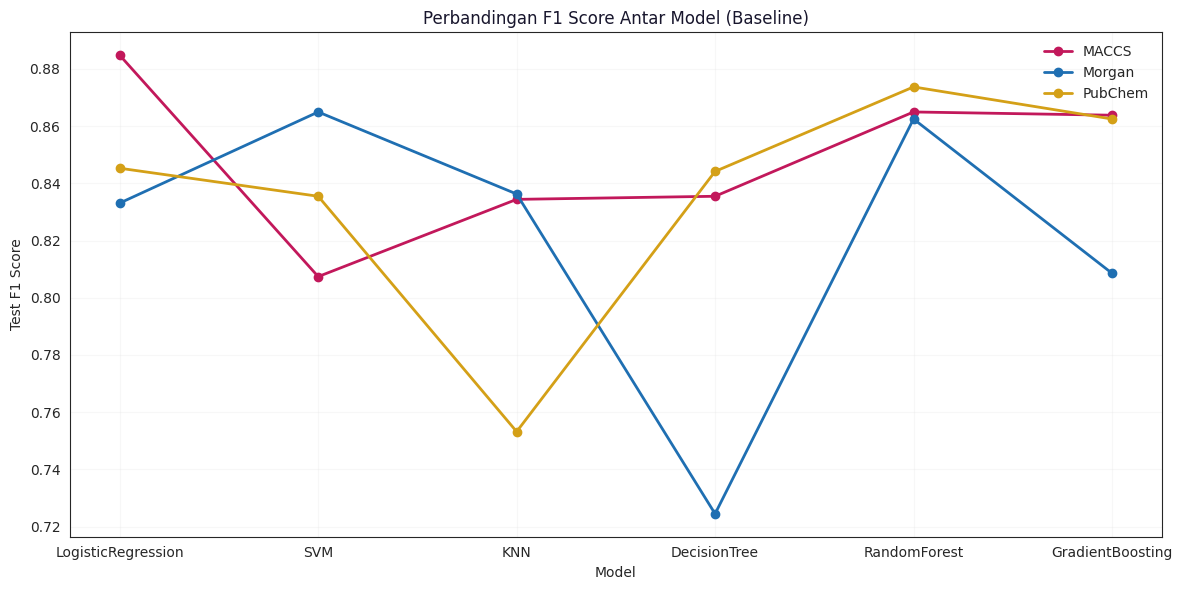

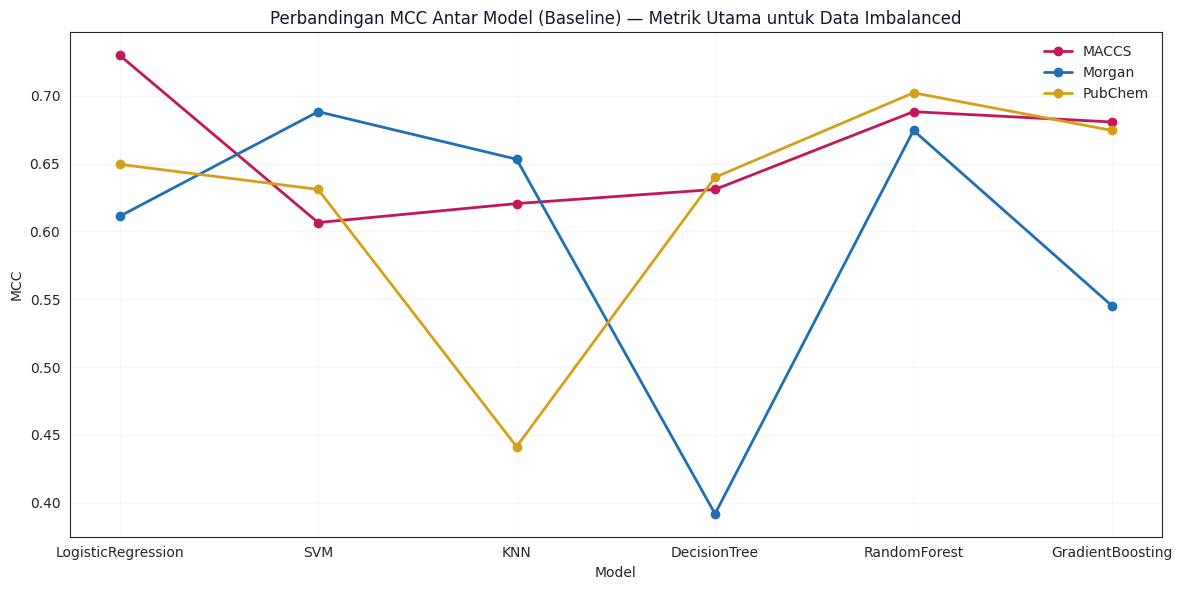

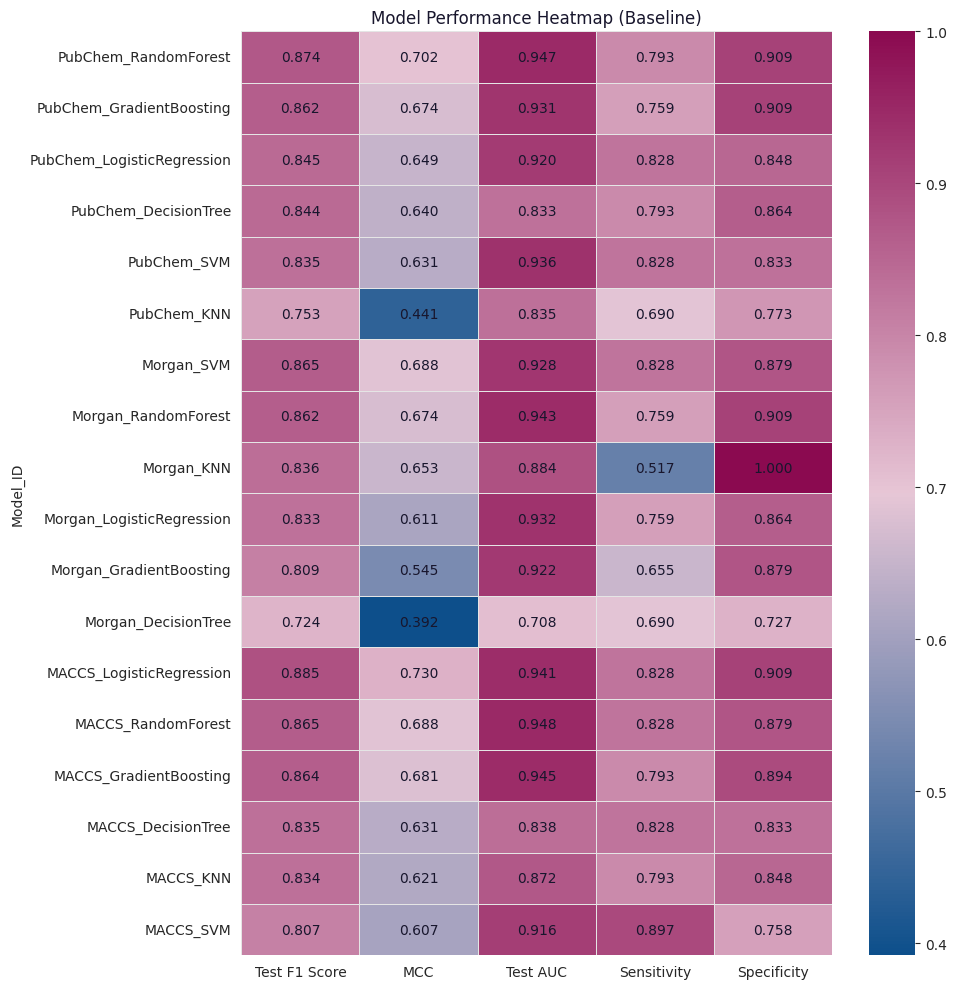

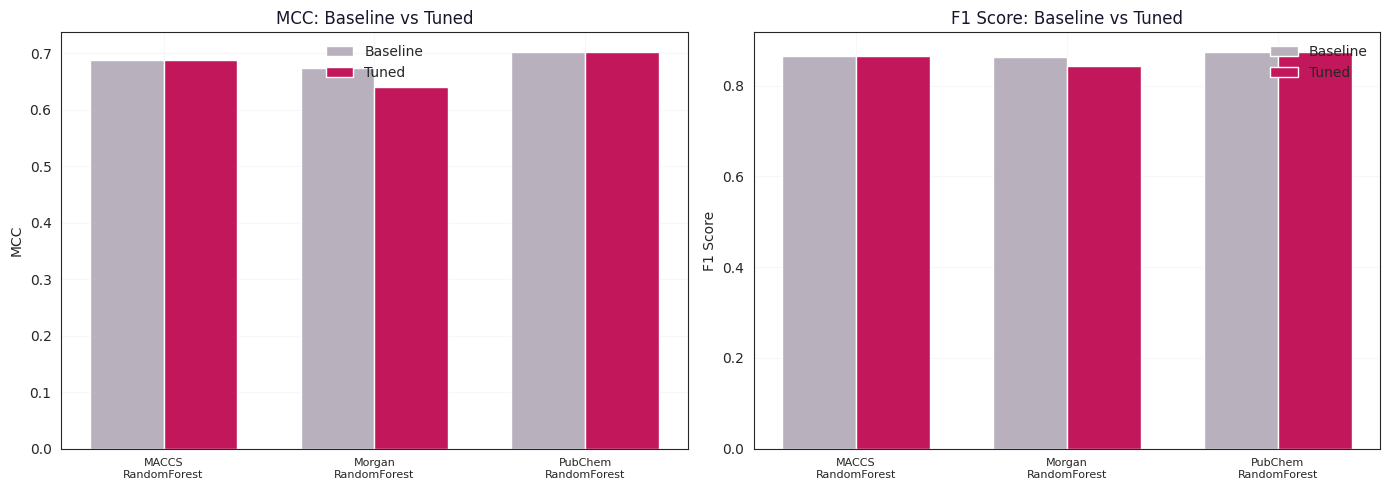


TAHAP 10 selesai: Seluruh visualisasi perbandingan tersimpan.


In [ ]:
# ================================================================
# TAHAP 10 — VISUALISASI PERBANDINGAN MENYELURUH
# ================================================================
# Tujuan: grafik perbandingan F1/MCC antar model (baseline) per
# fingerprint, heatmap performa, dan grafik baseline-vs-tuned.

# --- 10.0 Pemetaan warna tetap untuk 3 fingerprint (konsisten di semua grafik) ---
FINGERPRINT_COLOR_MAP = {
    "MACCS": project_colors["up"],
    "Morgan": project_colors["down"],
    "PubChem": project_colors["gold"],
}

# --- 10.1 Perbandingan F1 Score antar model (baseline) ---
plt.figure(figsize=(12, 6))
for fp_name in FINGERPRINT_FILES.keys():
    subset = results_df[results_df["Fingerprint"] == fp_name].copy()
    subset["Model"] = pd.Categorical(subset["Model"], categories=MODEL_ORDER, ordered=True)
    subset = subset.sort_values("Model")
    plt.plot(subset["Model"], subset["Test F1 Score"], marker="o", linewidth=2,
              label=fp_name, color=FINGERPRINT_COLOR_MAP[fp_name])

plt.xlabel("Model")
plt.ylabel("Test F1 Score")
plt.title("Perbandingan F1 Score Antar Model (Baseline)")
plt.grid(True, alpha=0.3, color=project_colors["grid"])
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "F1_Comparison_Baseline.png"), dpi=300)
plt.show()

# --- 10.2 Perbandingan MCC antar model (baseline) — metrik utama ---
plt.figure(figsize=(12, 6))
for fp_name in FINGERPRINT_FILES.keys():
    subset = results_df[results_df["Fingerprint"] == fp_name].copy()
    subset["Model"] = pd.Categorical(subset["Model"], categories=MODEL_ORDER, ordered=True)
    subset = subset.sort_values("Model")
    plt.plot(subset["Model"], subset["MCC"], marker="o", linewidth=2,
              label=fp_name, color=FINGERPRINT_COLOR_MAP[fp_name])

plt.xlabel("Model")
plt.ylabel("MCC")
plt.title("Perbandingan MCC Antar Model (Baseline) — Metrik Utama untuk Data Imbalanced")
plt.grid(True, alpha=0.3, color=project_colors["grid"])
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "MCC_Comparison_Baseline.png"), dpi=300)
plt.show()

# --- 10.3 Heatmap performa seluruh kombinasi model x fingerprint ---
heatmap_df = results_df.copy()
heatmap_df["Model_ID"] = heatmap_df["Fingerprint"] + "_" + heatmap_df["Model"]
heatmap_df = heatmap_df.set_index("Model_ID")
heatmap_data = heatmap_df[["Test F1 Score", "MCC", "Test AUC", "Sensitivity", "Specificity"]]

plt.figure(figsize=(10, 10))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f",
    cmap=project_diverging_cmap,
    linewidths=0.5, linecolor=project_colors["grid"],
    annot_kws={"color": project_colors["text"]}
)
plt.title("Model Performance Heatmap (Baseline)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "Model_Performance_Heatmap.png"), dpi=300)
plt.show()

# --- 10.4 Baseline vs Tuned (jika tuning dijalankan) ---
if RUN_HYPERPARAMETER_TUNING and len(comparison_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(comparison_df))
    width = 0.35

    axes[0].bar(x - width/2, comparison_df["MCC_Baseline"], width, label="Baseline", color=project_colors["ns"])
    axes[0].bar(x + width/2, comparison_df["MCC_Tuned"], width, label="Tuned", color=project_colors["up"])
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(comparison_df["Fingerprint"] + "\n" + comparison_df["Model"], fontsize=8)
    axes[0].set_ylabel("MCC")
    axes[0].set_title("MCC: Baseline vs Tuned")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, color=project_colors["grid"])

    axes[1].bar(x - width/2, comparison_df["F1_Baseline"], width, label="Baseline", color=project_colors["ns"])
    axes[1].bar(x + width/2, comparison_df["F1_Tuned"], width, label="Tuned", color=project_colors["up"])
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(comparison_df["Fingerprint"] + "\n" + comparison_df["Model"], fontsize=8)
    axes[1].set_ylabel("F1 Score")
    axes[1].set_title("F1 Score: Baseline vs Tuned")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, color=project_colors["grid"])

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, "Baseline_vs_Tuned_Comparison.png"), dpi=300)
    plt.show()

print("\nTAHAP 10 selesai: Seluruh visualisasi perbandingan tersimpan.")



,Fingerprint,Model,Stage,Composite_Rank_Global,MCC,Test F1 Score,Test AUC
0,PubChem,RandomForest,Baseline,12.0,0.702194,0.873684,0.946970
1,MACCS,RandomForest,Tuned,26.0,0.688273,0.864932,0.945664
2,Morgan,RandomForest,Baseline,26.0,0.674440,0.862472,0.943312


MODEL FINAL TERPILIH (Baseline): PubChem - RandomForest
Composite_Rank_Global (semakin kecil semakin baik, gabungan 11 metrik): 12
MCC  : 0.7022
F1   : 0.8737
AUC  : 0.9470

Perbandingan MCC: Single-split (n=95) = 0.7022 vs Cross-Val Predict (n=475) = 0.6546
Perbandingan F1 : Single-split (n=95) = 0.8737 vs Cross-Val Predict (n=475) = 0.8537
Selisih MCC single-split vs CV relatif kecil (0.0476) -> hasil cukup konsisten.


,Fingerprint,Model,MCC_SingleSplit,MCC_CrossValPredict,MCC_Gap,F1_SingleSplit,F1_CrossValPredict
0,PubChem,RandomForest,0.702194,0.654628,0.047567,0.873684,0.853717


<Figure size 500x500 with 0 Axes>

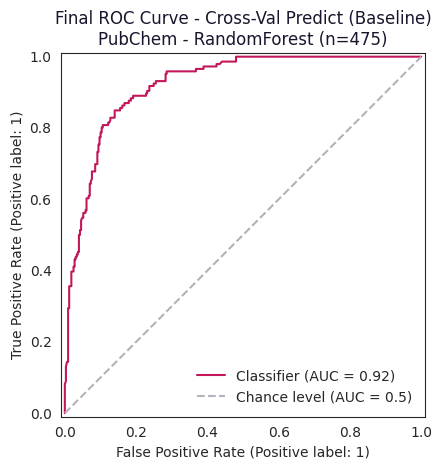

,Feature,Importance
0,PubChem_bits199,0.049172
1,PubChem_on_bits,0.048132
2,PubChem_bits192,0.040236
3,PubChem_bits797,0.038426
4,PubChem_bits186,0.035821
5,PubChem_bits193,0.017585
6,PubChem_bits185,0.016729
7,PubChem_bits734,0.015640
8,PubChem_bits819,0.013934
9,PubChem_bits818,0.013850


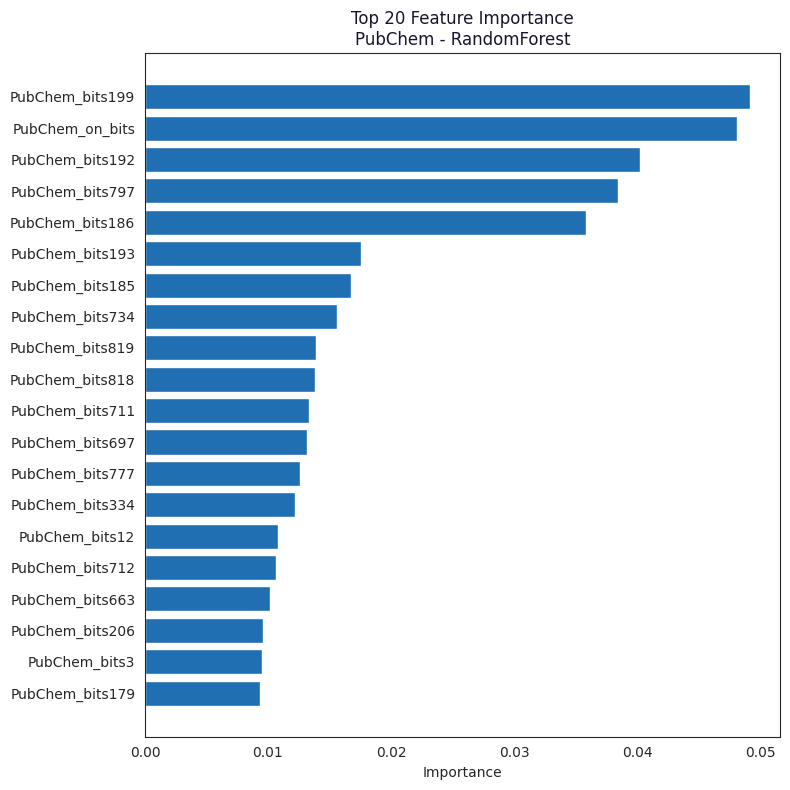


>> INTERPRETASI [Feature Importance — Fitur Fingerprint Paling Berpengaruh]
Fitur paling berpengaruh adalah **PubChem_bits199** dengan kontribusi 4.9% dari total importance seluruh fitur. Top-5 fitur menyumbang 21.2% dari total importance. Metode perhitungan: feature_importances_ (tree-based: Gini/impurity importance). Importance tersebar cukup merata di banyak fitur (top-5 hanya 21.2%) -- model mengandalkan KOMBINASI banyak bit fingerprint, bukan beberapa fitur dominan. Ini umumnya menandakan pola yang lebih kompleks/holistik, namun juga lebih sulit diinterpretasi secara kimiawi dibanding model dengan sedikit fitur dominan.

Jumlah prediksi salah (Cross-Val Predict, n=475): 69 sampel (14.5%)
  - False Positive (diprediksi High Binding, sebenarnya Low) : 31
  - False Negative (diprediksi Low Binding, sebenarnya High): 38


,best_affinity_kcal_mol,Label,y_pred,y_prob
10,-9.008,1,0,0.306000
19,-9.101,1,0,0.179389
22,-9.779,1,0,0.064000
33,-8.598,0,1,0.602779
38,-8.829,0,1,0.672000
48,-9.001,1,0,0.236000
108,-10.845,1,0,0.278662
130,-9.321,1,0,0.226000
142,-10.356,1,0,0.346000
143,-8.226,0,1,0.768000



>> INTERPRETASI [Error Analysis — Pola Kesalahan Klasifikasi]
Dari 475 sampel (Cross-Val Predict), 69 (14.5%) diprediksi salah: 31 False Positive dan 38 False Negative. Jumlah False Positive dan False Negative relatif SEIMBANG -- model tidak bias ke arah tertentu dalam jenis kesalahannya.

Threshold default (0.5) -> F1 (Cross-Val Predict): 0.8537
Threshold optimal (~0.445) -> F1: 0.7893
Catatan: pertimbangkan threshold ini jika ingin menyeimbangkan precision/recall lebih baik,
         terutama karena dataset imbalanced membuat threshold 0.5 belum tentu ideal.


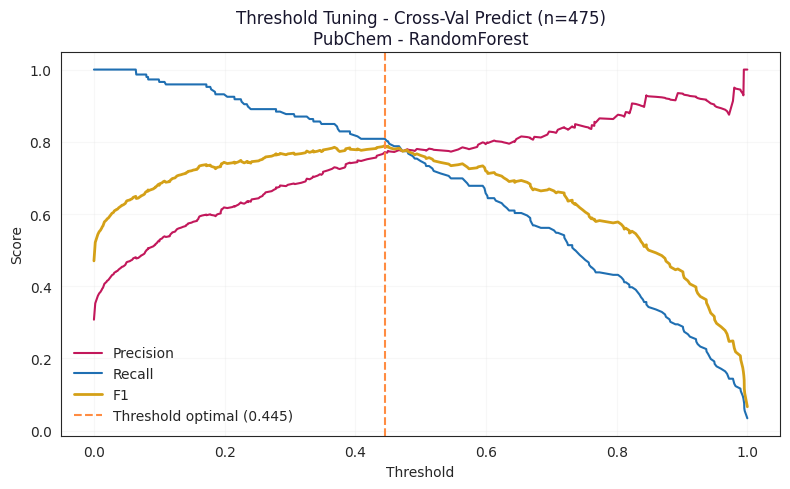

,Fingerprint,Model,N_Samples_Used,Default_Threshold,Default_F1_Weighted,Optimal_Threshold,Optimal_F1
0,PubChem,RandomForest,475,0.5,0.853717,0.445164,0.789298



>> INTERPRETASI [Threshold Tuning — Titik Potong Optimal untuk Data Imbalanced]
Threshold default (0.5) menghasilkan F1=0.8537, sementara threshold optimal (0.445) menghasilkan F1=0.7893 (selisih -0.0644). Threshold optimal LEBIH RENDAH dari 0.5 (turun 0.055) -- model sebaiknya dibuat lebih 'permisif' dalam menandai High Binding (memprediksi 1 walau probabilitasnya belum sampai 0.5). Ini cocok jika tujuan utama adalah TIDAK MELEWATKAN kandidat senyawa potensial (meminimalkan False Negative), dengan konsekuensi lebih banyak False Positive yang perlu disaring di tahap validasi berikutnya. **Rekomendasi praktis**: jika model ini dipakai untuk skrining senyawa baru, gunakan threshold 0.445 (bukan default 0.5) saat memanggil `predict_proba()` secara manual, kecuali ada pertimbangan domain spesifik yang lebih diutamakan.


,Fingerprint,Model,Stage,Evaluation_Method,N_Samples,Accuracy,F1 (Weighted),AUC,Sensitivity,Specificity,MCC
0,PubChem,RandomForest,Baseline,Single-Split (20% test),95,0.873684,0.873684,0.946970,0.793103,0.909091,0.702194
1,PubChem,RandomForest,Baseline,Cross-Val Predict (n penuh),475,0.854737,0.853717,0.922513,0.739726,0.905775,0.654628



Catatan: gunakan baris 'Cross-Val Predict' sebagai acuan performa yang lebih stabil/representatif;
         baris 'Single-Split' ditampilkan untuk transparansi proses seleksi model (Tahap 7-9).

Model final (di-fit ulang pada seluruh data, n=475) disimpan ke:
/content/drive/MyDrive/Breast Cancer Model/ML_Result6/models/FINAL_MODEL_PubChem_RandomForest_Baseline.joblib
Catatan: model ini dilatih pada seluruh data yang tersedia agar siap pakai untuk prediksi baru.
         Estimasi performa yang valid untuk dilaporkan adalah hasil CV/Cross-Val Predict di atas,
         BUKAN dengan menguji ulang model ini pada X_test (karena X_test sudah ikut dilatih).

TAHAP 11 selesai: Feature importance, error analysis, threshold tuning, dan model final tersimpan.


In [ ]:
# ================================================================
# TAHAP 11 — ANALISIS AKHIR: FEATURE IMPORTANCE, ERROR ANALYSIS,
#            THRESHOLD TUNING, & PENYIMPANAN MODEL FINAL
# ================================================================
# Tujuan: pendalaman analisis untuk model FINAL (tuned terbaik secara
# global), meliputi: feature importance (jika model mendukung),
# analisis kesalahan klasifikasi, threshold tuning untuk data
# imbalanced (precision-recall trade-off), dan penyimpanan model.

# --- 11.1 Tentukan model final terbaik secara global (lintas fingerprint) ---
# Logika: untuk tiap fingerprint, pakai stage (Baseline/Tuned) yang MENANG
# head-to-head di Tahap 9 (komparasi composite rank apel-ke-apel). Lalu di
# antara 3 kandidat terbaik (satu per fingerprint), pilih yang Composite_Rank
# globalnya (dihitung ulang lintas 3 kandidat ini) paling kecil.

candidate_rows = []

for _, row in best_per_fp.iterrows():
    fp_name, model_name = row["Fingerprint"], row["Model"]

    if RUN_HYPERPARAMETER_TUNING and len(tuned_results_df) > 0:
        comp_row = comparison_df[comparison_df["Fingerprint"] == fp_name].iloc[0]
        if comp_row["Pemenang_HeadToHead"] == "Tuned":
            chosen_stage = "Tuned"
            chosen_metrics = tuned_results_df[tuned_results_df["Fingerprint"] == fp_name].iloc[0]
            chosen_obj = tuned_models[fp_name]
        else:
            chosen_stage = "Baseline"
            chosen_metrics = row
            chosen_obj = trained_models[fp_name][model_name]
    else:
        chosen_stage = "Baseline"
        chosen_metrics = row
        chosen_obj = trained_models[fp_name][model_name]

    candidate = {c: chosen_metrics[c] for c in COMPOSITE_RANK_METRICS}
    candidate["Fingerprint"] = fp_name
    candidate["Model"] = model_name
    candidate["Stage"] = chosen_stage
    candidate_rows.append(candidate)

candidates_df = pd.DataFrame(candidate_rows)
for col in COMPOSITE_RANK_METRICS:
    candidates_df[col + "_Rank"] = candidates_df[col].rank(ascending=False, method="min")
candidates_df["Composite_Rank_Global"] = candidates_df[[c + "_Rank" for c in COMPOSITE_RANK_METRICS]].sum(axis=1)
candidates_df = candidates_df.sort_values("Composite_Rank_Global", ascending=True).reset_index(drop=True)

display(candidates_df[["Fingerprint", "Model", "Stage", "Composite_Rank_Global", "MCC", "Test F1 Score", "Test AUC"]])
candidates_df.to_excel(os.path.join(TABLE_DIR, "final_candidates_composite_rank.xlsx"), index=False)

final_candidate = candidates_df.iloc[0]
final_fp = final_candidate["Fingerprint"]
final_model_name = final_candidate["Model"]
stage_label = final_candidate["Stage"]

if stage_label == "Tuned":
    final_obj = tuned_models[final_fp]
else:
    final_obj = trained_models[final_fp][final_model_name]

final_model = final_obj["model"]
final_row = final_candidate

X_train = final_obj["X_train"]
X_test = final_obj["X_test"]
y_train = final_obj["y_train"]
y_test = final_obj["y_test"]
y_pred = final_obj["y_pred"]
y_prob = final_obj["y_prob"]
cm = final_obj["confusion_matrix"]

print("="*70)
print(f"MODEL FINAL TERPILIH ({stage_label}): {final_fp} - {final_model_name}")
print(f"Composite_Rank_Global (semakin kecil semakin baik, gabungan {len(COMPOSITE_RANK_METRICS)} metrik): "
      f"{final_row['Composite_Rank_Global']:.0f}")
print(f"MCC  : {final_row['MCC']:.4f}")
print(f"F1   : {final_row['Test F1 Score']:.4f}")
print(f"AUC  : {final_row['Test AUC']:.4f}")
print("="*70)

# ----------------------------------------------------------------
# 11.1b PENDEKATAN HYBRID: cross_val_predict UNTUK ANALISIS YANG STABIL
# ----------------------------------------------------------------
# MASALAH dengan single train/test split (20% test = hanya ~40 sampel
# pada dataset ~200 baris): confusion matrix, ROC, feature importance,
# dan error analysis yang dihitung dari situ SANGAT rentan "untung-
# untungan" -- 1-2 sampel kelas minoritas yang kebetulan masuk test
# bisa mengubah hasil secara drastis (lihat Tahap 13 untuk pembuktian
# numeriknya lewat multi-seed).
#
# SOLUSI (hybrid): untuk analisis di bawah (confusion matrix, ROC,
# error analysis, threshold tuning), prediksi dihasilkan lewat
# cross_val_predict pada SELURUH data (bukan cuma 20% test) -- setiap
# sampel diprediksi tepat 1 kali, saat berada di fold test, sehingga
# tetap "out-of-sample" tapi mencakup seluruh ~200 sampel, bukan ~40.
# Model FINAL yang disimpan ke disk tetap di-fit pada X_train asli
# (atau seluruh X jika ingin dipakai produksi -- lihat 11.7), sehingga
# tidak ada kebocoran data ke proses pemilihan model di Tahap 7-9.

X_full = prepared_data[final_fp]["X"]
y_full = prepared_data[final_fp]["y"]

# Model fresh (belum di-fit) dengan hyperparameter yang sama dengan model final,
# supaya cross_val_predict tidak memakai model yang sudah "melihat" data tertentu.
if stage_label == "Tuned":
    cv_predict_model = final_model.__class__(**final_model.get_params()) if not hasattr(final_model, "named_steps") \
        else Pipeline([(name, step.__class__(**step.get_params())) for name, step in final_model.named_steps.items()])
else:
    cv_predict_model = build_models()[final_model_name]
    # Pastikan hyperparameter sama dengan model final (penting jika final adalah hasil tuning)
    cv_predict_model = final_model.__class__(**final_model.get_params()) if not hasattr(final_model, "named_steps") \
        else Pipeline([(name, step.__class__(**step.get_params())) for name, step in final_model.named_steps.items()])

y_pred_cv = cross_val_predict(cv_predict_model, X_full, y_full, cv=cv_strategy, n_jobs=-1)

if hasattr(cv_predict_model, "predict_proba") or (
    hasattr(cv_predict_model, "named_steps") and hasattr(cv_predict_model.named_steps.get("model"), "predict_proba")
):
    y_prob_cv = cross_val_predict(cv_predict_model, X_full, y_full, cv=cv_strategy, method="predict_proba", n_jobs=-1)[:, 1]
else:
    y_prob_cv = None

mcc_single_split = matthews_corrcoef(y_test, y_pred)
mcc_cv = matthews_corrcoef(y_full, y_pred_cv)
f1_single_split = f1_score(y_test, y_pred, average="weighted")
f1_cv = f1_score(y_full, y_pred_cv, average="weighted")

print(f"\nPerbandingan MCC: Single-split (n={len(y_test)}) = {mcc_single_split:.4f} "
      f"vs Cross-Val Predict (n={len(y_full)}) = {mcc_cv:.4f}")
print(f"Perbandingan F1 : Single-split (n={len(y_test)}) = {f1_single_split:.4f} "
      f"vs Cross-Val Predict (n={len(y_full)}) = {f1_cv:.4f}")
gap_mcc = abs(mcc_single_split - mcc_cv)
if gap_mcc > 0.15:
    interp_text = (
        f"Selisih MCC antara Single-Split ({mcc_single_split:.4f}, n={len(y_test)}) dan "
        f"Cross-Val Predict ({mcc_cv:.4f}, n={len(y_full)}) adalah {gap_mcc:.4f} -- CUKUP BESAR "
        f"(melebihi pengamatan wajar ~0.15). Ini berarti angka performa dari single-split pada "
        f"Tahap 7-9 kemungkinan TERPENGARUH KEBETULAN pembagian data (hanya ~{len(y_test)} sampel "
        f"test). **Rekomendasi**: gunakan angka Cross-Val Predict (berbasis {len(y_full)} sampel) "
        f"sebagai acuan performa yang lebih dapat dipercaya untuk pelaporan akhir."
    )
    print(f"PERINGATAN: selisih MCC single-split vs CV cukup besar ({gap_mcc:.4f}) -> "
          f"hasil single-split sebelumnya kemungkinan terpengaruh kebetulan pembagian data. "
          f"Gunakan angka Cross-Val Predict di bawah sebagai acuan yang lebih stabil.")
else:
    interp_text = (
        f"Selisih MCC antara Single-Split ({mcc_single_split:.4f}) dan Cross-Val Predict "
        f"({mcc_cv:.4f}) hanya {gap_mcc:.4f} -- relatif KECIL. Ini menandakan performa model "
        f"cukup konsisten terlepas dari metode evaluasi yang dipakai, sehingga hasil pada Tahap 7-9 "
        f"cukup dapat dipercaya tanpa banyak distorsi dari kebetulan pembagian data."
    )
    print(f"Selisih MCC single-split vs CV relatif kecil ({gap_mcc:.4f}) -> hasil cukup konsisten.")

log_interpretation(
    tahap="11",
    judul="Single-Split vs Cross-Val Predict (Validitas Estimasi Performa)",
    narasi=interp_text,
    print_now=False   # sudah ditampilkan manual di atas, hindari duplikasi print
)

split_vs_cv_df = pd.DataFrame([{
    "Fingerprint": final_fp,
    "Model": final_model_name,
    "MCC_SingleSplit": mcc_single_split,
    "MCC_CrossValPredict": mcc_cv,
    "MCC_Gap": gap_mcc,
    "F1_SingleSplit": f1_single_split,
    "F1_CrossValPredict": f1_cv,
}])
display(split_vs_cv_df)
split_vs_cv_df.to_excel(os.path.join(TABLE_DIR, "Final_Model_SingleSplit_vs_CV.xlsx"), index=False)

# Variabel di bawah ini (USED FOR ANALYSIS) memakai hasil Cross-Val Predict
# sebagai sumber utama analisis 11.2-11.5, sesuai pendekatan hybrid.
y_test_analysis = y_full
y_pred_analysis = y_pred_cv
y_prob_analysis = y_prob_cv
analysis_index = y_full.index

# --- 11.2 ROC curve final (berbasis Cross-Val Predict, n penuh) ---
if y_prob_analysis is not None:
    plot_roc_curve_styled(
        y_test_analysis, y_prob_analysis,
        title=f"Final ROC Curve - Cross-Val Predict ({stage_label})\n{final_fp} - {final_model_name} (n={len(y_test_analysis)})",
        save_path=os.path.join(FIGURE_DIR, "FINAL_ROC.png")
    )
    plt.show()
else:
    print(f"Model {final_model_name} tidak punya predict_proba -> ROC curve dilewati.")

# --- 11.3 Feature importance (jika model mendukung) ---
feature_cols = prepared_data[final_fp]["feature_cols"]

# Ambil estimator inti dari Pipeline jika perlu
core_model = final_model.named_steps["model"] if hasattr(final_model, "named_steps") else final_model

importance_df = None
if hasattr(core_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": core_model.feature_importances_
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
elif hasattr(core_model, "coef_"):
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": np.abs(core_model.coef_[0])
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

if importance_df is not None:
    top_n = 20
    display(importance_df.head(top_n))
    importance_df.to_excel(os.path.join(TABLE_DIR, "Final_Model_Feature_Importance.xlsx"), index=False)

    plt.figure(figsize=(8, 8))
    top_features = importance_df.head(top_n)
    plt.barh(top_features["Feature"], top_features["Importance"], color=project_colors["down"])
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importance\n{final_fp} - {final_model_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, "Final_Model_Feature_Importance.png"), dpi=300)
    plt.show()

    top1_feature = importance_df.iloc[0]
    top1_share = top1_feature["Importance"] / importance_df["Importance"].sum() * 100
    top5_share = importance_df.head(5)["Importance"].sum() / importance_df["Importance"].sum() * 100
    importance_method = "feature_importances_ (tree-based: Gini/impurity importance)" \
        if hasattr(core_model, "feature_importances_") else "|coefficient| (Logistic Regression)"

    importance_narasi = (
        f"Fitur paling berpengaruh adalah **{top1_feature['Feature']}** dengan kontribusi "
        f"{top1_share:.1f}% dari total importance seluruh fitur. Top-5 fitur menyumbang "
        f"{top5_share:.1f}% dari total importance. Metode perhitungan: {importance_method}. "
    )
    if top1_share > 30:
        importance_narasi += (
            f"PERHATIAN: 1 fitur tunggal mendominasi >30% importance -- model SANGAT bergantung "
            f"pada bit fingerprint ini. Ini bisa berarti bit tersebut memang sangat informatif "
            f"secara kimiawi (representasi gugus fungsi yang relevan dengan binding), TAPI juga "
            f"berisiko model kurang robust jika bit tersebut bernilai sama untuk senyawa baru "
            f"yang sebenarnya berbeda karakteristik bindingnya. Disarankan menelusuri arti "
            f"struktural bit ini (substruktur SMARTS yang diwakilinya) untuk validasi domain kimia."
        )
    elif top5_share < 30:
        importance_narasi += (
            f"Importance tersebar cukup merata di banyak fitur (top-5 hanya {top5_share:.1f}%) -- "
            f"model mengandalkan KOMBINASI banyak bit fingerprint, bukan beberapa fitur dominan. "
            f"Ini umumnya menandakan pola yang lebih kompleks/holistik, namun juga lebih sulit "
            f"diinterpretasi secara kimiawi dibanding model dengan sedikit fitur dominan."
        )
    else:
        importance_narasi += (
            "Distribusi importance tergolong wajar -- tidak ada satu fitur yang terlalu dominan, "
            "namun beberapa fitur teratas tetap punya kontribusi yang jelas terlihat."
        )

    log_interpretation(
        tahap="11",
        judul="Feature Importance — Fitur Fingerprint Paling Berpengaruh",
        narasi=importance_narasi
    )
else:
    print(f"Model {final_model_name} tidak menyediakan feature_importances_/coef_ secara langsung "
          f"(misal: KNN, SVM non-linear) -> feature importance dilewati.")


# --- 11.4 Error analysis (berbasis Cross-Val Predict, mencakup SELURUH
#     ~200 sampel -- bukan hanya ~40 sampel test split, sehingga pola
#     kesalahan yang ditemukan lebih representatif, bukan kebetulan) ---
test_data = prepared_data[final_fp]["data"].loc[analysis_index].copy()
test_data["y_true"] = y_test_analysis.values
test_data["y_pred"] = y_pred_analysis
if y_prob_analysis is not None:
    test_data["y_prob"] = y_prob_analysis
test_data["correct"] = test_data["y_true"] == test_data["y_pred"]

errors_df = test_data[~test_data["correct"]].copy()
print(f"\nJumlah prediksi salah (Cross-Val Predict, n={len(test_data)}): {len(errors_df)} sampel "
      f"({len(errors_df)/len(test_data)*100:.1f}%)")

# Pisahkan jenis kesalahan: False Positive vs False Negative
fp_errors = errors_df[(errors_df["y_true"] == 0) & (errors_df["y_pred"] == 1)]
fn_errors = errors_df[(errors_df["y_true"] == 1) & (errors_df["y_pred"] == 0)]
print(f"  - False Positive (diprediksi High Binding, sebenarnya Low) : {len(fp_errors)}")
print(f"  - False Negative (diprediksi Low Binding, sebenarnya High): {len(fn_errors)}")

error_cols = [AFFINITY_COL, LABEL_COL, "y_pred"] + (["y_prob"] if y_prob_analysis is not None else [])
display(errors_df[error_cols].head(15))
errors_df[error_cols].to_excel(os.path.join(TABLE_DIR, "Final_Model_Misclassified_Samples.xlsx"), index=False)

error_rate = len(errors_df) / len(test_data) * 100
n_class1_total = int((test_data["y_true"] == 1).sum())
fn_rate_of_class1 = (len(fn_errors) / n_class1_total * 100) if n_class1_total > 0 else np.nan

error_narasi = (
    f"Dari {len(test_data)} sampel (Cross-Val Predict), {len(errors_df)} ({error_rate:.1f}%) "
    f"diprediksi salah: {len(fp_errors)} False Positive dan {len(fn_errors)} False Negative. "
)
if len(fn_errors) > len(fp_errors) * 1.5:
    error_narasi += (
        f"Model lebih banyak melakukan False Negative -- artinya CENDERUNG MELEWATKAN senyawa "
        f"yang sebenarnya High Binding ({fn_rate_of_class1:.1f}% dari {n_class1_total} sampel "
        f"High Binding aktual gagal terdeteksi). Untuk drug discovery, False Negative berarti "
        f"senyawa potensial (binding kuat) terlewat dari skrining -- ini berisiko menghilangkan "
        f"kandidat obat yang sebenarnya menjanjikan. Jika menghindari False Negative lebih "
        f"penting daripada menghindari False Positive, pertimbangkan menurunkan threshold "
        f"klasifikasi (lihat hasil Threshold Tuning di bawah)."
    )
elif len(fp_errors) > len(fn_errors) * 1.5:
    error_narasi += (
        f"Model lebih banyak melakukan False Positive -- artinya CENDERUNG OVER-PREDICT High "
        f"Binding pada senyawa yang sebenarnya Low Binding. Untuk drug discovery, ini berarti "
        f"lebih banyak kandidat 'palsu' yang akan lolos ke tahap validasi laboratorium "
        f"(uji in-vitro/in-vivo) yang mahal dan memakan waktu, padahal sebenarnya tidak berikatan "
        f"kuat. Jika efisiensi biaya validasi lebih penting, pertimbangkan menaikkan threshold."
    )
else:
    error_narasi += (
        "Jumlah False Positive dan False Negative relatif SEIMBANG -- model tidak bias ke arah "
        "tertentu dalam jenis kesalahannya."
    )

log_interpretation(
    tahap="11",
    judul="Error Analysis — Pola Kesalahan Klasifikasi",
    narasi=error_narasi
)


# --- 11.5 Threshold tuning (berbasis Cross-Val Predict, n penuh) ---
# Default threshold 0.5 belum tentu optimal pada data imbalanced.
# Dicari threshold yang memaksimalkan F1, dihitung dari prediksi
# out-of-fold (n penuh) supaya tidak terpengaruh kebetulan 1 split kecil.
if y_prob_analysis is not None:
    precisions, recalls, thresholds = precision_recall_curve(y_test_analysis, y_prob_analysis)
    f1_scores = np.where(
        (precisions + recalls) > 0,
        2 * precisions * recalls / (precisions + recalls + 1e-12),
        0
    )
    best_idx = np.argmax(f1_scores[:-1])  # thresholds punya panjang len-1 dibanding precision/recall
    best_threshold = thresholds[best_idx]
    best_f1_at_threshold = f1_scores[best_idx]

    print(f"\nThreshold default (0.5) -> F1 (Cross-Val Predict): "
          f"{f1_score(y_test_analysis, y_pred_analysis, average='weighted'):.4f}")
    print(f"Threshold optimal (~{best_threshold:.3f}) -> F1: {best_f1_at_threshold:.4f}")
    print("Catatan: pertimbangkan threshold ini jika ingin menyeimbangkan precision/recall lebih baik,")
    print("         terutama karena dataset imbalanced membuat threshold 0.5 belum tentu ideal.")

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precisions[:-1], label="Precision", color=project_colors["up"])
    plt.plot(thresholds, recalls[:-1], label="Recall", color=project_colors["down"])
    plt.plot(thresholds, f1_scores[:-1], label="F1", linewidth=2, color=project_colors["gold"])
    plt.axvline(best_threshold, color=project_colors["outlier"], linestyle="--",
                label=f"Threshold optimal ({best_threshold:.3f})")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Tuning - Cross-Val Predict (n={len(y_test_analysis)})\n{final_fp} - {final_model_name}")
    plt.legend()
    plt.grid(True, alpha=0.3, color=project_colors["grid"])
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, "Final_Model_Threshold_Tuning.png"), dpi=300)
    plt.show()

    threshold_summary_df = pd.DataFrame([{
        "Fingerprint": final_fp,
        "Model": final_model_name,
        "N_Samples_Used": len(y_test_analysis),
        "Default_Threshold": 0.5,
        "Default_F1_Weighted": f1_score(y_test_analysis, y_pred_analysis, average="weighted"),
        "Optimal_Threshold": best_threshold,
        "Optimal_F1": best_f1_at_threshold
    }])
    display(threshold_summary_df)
    threshold_summary_df.to_excel(os.path.join(TABLE_DIR, "Final_Model_Threshold_Tuning.xlsx"), index=False)

    default_f1 = f1_score(y_test_analysis, y_pred_analysis, average="weighted")
    f1_gain = best_f1_at_threshold - default_f1
    threshold_shift = best_threshold - 0.5

    threshold_narasi = (
        f"Threshold default (0.5) menghasilkan F1={default_f1:.4f}, sementara threshold optimal "
        f"({best_threshold:.3f}) menghasilkan F1={best_f1_at_threshold:.4f} "
        f"(selisih {f1_gain:+.4f}). "
    )
    if abs(f1_gain) < 0.02:
        threshold_narasi += (
            "Selisihnya KECIL -- threshold default 0.5 sudah cukup baik, tidak perlu diubah "
            "untuk pemakaian umum."
        )
    elif threshold_shift < 0:
        threshold_narasi += (
            f"Threshold optimal LEBIH RENDAH dari 0.5 (turun {abs(threshold_shift):.3f}) -- model "
            f"sebaiknya dibuat lebih 'permisif' dalam menandai High Binding (memprediksi 1 walau "
            f"probabilitasnya belum sampai 0.5). Ini cocok jika tujuan utama adalah TIDAK MELEWATKAN "
            f"kandidat senyawa potensial (meminimalkan False Negative), dengan konsekuensi lebih "
            f"banyak False Positive yang perlu disaring di tahap validasi berikutnya."
        )
    else:
        threshold_narasi += (
            f"Threshold optimal LEBIH TINGGI dari 0.5 (naik {threshold_shift:.3f}) -- model "
            f"sebaiknya lebih 'ketat' sebelum menandai High Binding. Ini cocok jika validasi "
            f"laboratorium mahal/lambat dan ingin meminimalkan False Positive, dengan konsekuensi "
            f"berisiko melewatkan beberapa kandidat sebenarnya (False Negative)."
        )
    threshold_narasi += (
        f" **Rekomendasi praktis**: jika model ini dipakai untuk skrining senyawa baru, gunakan "
        f"threshold {best_threshold:.3f} (bukan default 0.5) saat memanggil `predict_proba()` "
        f"secara manual, kecuali ada pertimbangan domain spesifik yang lebih diutamakan."
    )

    log_interpretation(
        tahap="11",
        judul="Threshold Tuning — Titik Potong Optimal untuk Data Imbalanced",
        narasi=threshold_narasi
    )
else:
    print(f"Model {final_model_name} tidak punya predict_proba -> threshold tuning dilewati.")

# --- 11.6 Ringkasan metrik final (DUA versi: Single-Split & Cross-Val
#     Predict, berdampingan, supaya transparan keduanya) ---
final_metrics_df = pd.DataFrame([
    {
        "Fingerprint": final_fp,
        "Model": final_model_name,
        "Stage": stage_label,
        "Evaluation_Method": "Single-Split (20% test)",
        "N_Samples": len(y_test),
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (Weighted)": f1_score(y_test, y_pred, average="weighted"),
        "AUC": safe_roc_auc_score(y_test, y_prob),
        "Sensitivity": compute_specificity_sensitivity(y_test, y_pred)[2],
        "Specificity": compute_specificity_sensitivity(y_test, y_pred)[1],
        "MCC": matthews_corrcoef(y_test, y_pred)
    },
    {
        "Fingerprint": final_fp,
        "Model": final_model_name,
        "Stage": stage_label,
        "Evaluation_Method": "Cross-Val Predict (n penuh)",
        "N_Samples": len(y_test_analysis),
        "Accuracy": accuracy_score(y_test_analysis, y_pred_analysis),
        "F1 (Weighted)": f1_score(y_test_analysis, y_pred_analysis, average="weighted"),
        "AUC": safe_roc_auc_score(y_test_analysis, y_prob_analysis),
        "Sensitivity": compute_specificity_sensitivity(y_test_analysis, y_pred_analysis)[2],
        "Specificity": compute_specificity_sensitivity(y_test_analysis, y_pred_analysis)[1],
        "MCC": matthews_corrcoef(y_test_analysis, y_pred_analysis)
    }
])

display(final_metrics_df)
final_metrics_df.to_excel(os.path.join(TABLE_DIR, "Final_Model_Summary.xlsx"), index=False)
print("\nCatatan: gunakan baris 'Cross-Val Predict' sebagai acuan performa yang lebih stabil/representatif;")
print("         baris 'Single-Split' ditampilkan untuk transparansi proses seleksi model (Tahap 7-9).")

# --- 11.7 Penyimpanan model final ---
# Model di-fit ulang pada SELURUH data (X_full, y_full) sebelum disimpan,
# supaya model produksi yang dipakai untuk prediksi data baru nanti
# memanfaatkan seluruh informasi yang ada -- bukan hanya 80% data train.
# Ini AMAN dilakukan di sini karena seleksi model (Tahap 7-9) dan estimasi
# performa (di atas) sudah selesai dilakukan sebelum langkah ini.
final_model_for_production = final_model.__class__(**final_model.get_params()) if not hasattr(final_model, "named_steps") \
    else Pipeline([(name, step.__class__(**step.get_params())) for name, step in final_model.named_steps.items()])
final_model_for_production.fit(X_full, y_full)

model_save_path = os.path.join(MODEL_DIR, f"FINAL_MODEL_{final_fp}_{final_model_name}_{stage_label}.joblib")
joblib.dump(final_model_for_production, model_save_path)
print(f"\nModel final (di-fit ulang pada seluruh data, n={len(y_full)}) disimpan ke:")
print(model_save_path)
print("Catatan: model ini dilatih pada seluruh data yang tersedia agar siap pakai untuk prediksi baru.")
print("         Estimasi performa yang valid untuk dilaporkan adalah hasil CV/Cross-Val Predict di atas,")
print("         BUKAN dengan menguji ulang model ini pada X_test (karena X_test sudah ikut dilatih).")

print("\nTAHAP 11 selesai: Feature importance, error analysis, threshold tuning, dan model final tersimpan.")

TAHAP 12: UJI STATISTIK MODEL & FINGERPRINT
Metode CV untuk uji: Repeated Stratified K-Fold (5 repeats x 5 folds = 25 skor per model/fingerprint)
Metrik dasar uji   : MCC (Matthews Correlation Coefficient)
Tingkat signifikansi (alpha): 0.05

Menghitung skor Repeated CV (MCC) untuk setiap kombinasi fingerprint x model...
(proses ini berjalan agak lama karena setiap model dilatih 25 kali per fingerprint)

  MACCS    | LogisticRegression | mean MCC = 0.5524 (sd=0.0605)
  MACCS    | SVM                | mean MCC = 0.5882 (sd=0.0645)
  MACCS    | KNN                | mean MCC = 0.5803 (sd=0.0562)
  MACCS    | DecisionTree       | mean MCC = 0.5670 (sd=0.0776)
  MACCS    | RandomForest       | mean MCC = 0.6208 (sd=0.0661)
  MACCS    | GradientBoosting   | mean MCC = 0.5777 (sd=0.0688)
  Morgan   | LogisticRegression | mean MCC = 0.6013 (sd=0.0692)
  Morgan   | SVM                | mean MCC = 0.5871 (sd=0.0566)
  Morgan   | KNN                | mean MCC = 0.4667 (sd=0.0721)
  Morgan   | Deci

,LogisticRegression,SVM,KNN,DecisionTree,RandomForest,GradientBoosting
LogisticRegression,1.0000,0.1405,0.1988,0.6776,0.0007,0.1124
SVM,0.1405,1.0000,0.8501,0.2899,0.0539,0.9097
KNN,0.1988,0.8501,1.0000,0.3847,0.0343,0.7624
DecisionTree,0.6776,0.2899,0.3847,1.0000,0.0028,0.2413
RandomForest,0.0007,0.0539,0.0343,0.0028,1.0000,0.0696
GradientBoosting,0.1124,0.9097,0.7624,0.2413,0.0696,1.0000


Pasangan model dengan perbedaan SIGNIFIKAN (Nemenyi p < alpha):
   LogisticRegression vs RandomForest: p=0.0007 | effect size r=-0.520 (Large) | unggul: RandomForest
   KNN vs RandomForest: p=0.0343 | effect size r=-0.520 (Large) | unggul: RandomForest
   DecisionTree vs RandomForest: p=0.0028 | effect size r=-0.600 (Large) | unggul: RandomForest

--- Fingerprint: Morgan ---
Friedman test : statistic=53.3679, p-value=0.000000 -> SIGNIFIKAN (ada perbedaan antar model)
Critical Difference (CD) Nemenyi: 1.5079
Rata-rata rank tiap model (semakin kecil = semakin baik):
   LogisticRegression : rank rata-rata = 2.72
   SVM                : rank rata-rata = 3.10
   KNN                : rank rata-rata = 5.52
   DecisionTree       : rank rata-rata = 4.46
   RandomForest       : rank rata-rata = 2.68
   GradientBoosting   : rank rata-rata = 2.52


,LogisticRegression,SVM,KNN,DecisionTree,RandomForest,GradientBoosting
LogisticRegression,1.0000,0.4727,0.0000,0.0010,0.9397,0.7055
SVM,0.4727,1.0000,0.0000,0.0102,0.4274,0.2730
KNN,0.0000,0.0000,1.0000,0.0452,0.0000,0.0000
DecisionTree,0.0010,0.0102,0.0452,1.0000,0.0008,0.0002
RandomForest,0.9397,0.4274,0.0000,0.0008,1.0000,0.7624
GradientBoosting,0.7055,0.2730,0.0000,0.0002,0.7624,1.0000


Pasangan model dengan perbedaan SIGNIFIKAN (Nemenyi p < alpha):
   LogisticRegression vs KNN: p=0.0000 | effect size r=0.920 (Large) | unggul: LogisticRegression
   LogisticRegression vs DecisionTree: p=0.0010 | effect size r=0.583 (Large) | unggul: LogisticRegression
   SVM vs KNN: p=0.0000 | effect size r=0.920 (Large) | unggul: SVM
   SVM vs DecisionTree: p=0.0102 | effect size r=0.500 (Large) | unggul: SVM
   KNN vs DecisionTree: p=0.0452 | effect size r=-0.520 (Large) | unggul: DecisionTree
   KNN vs RandomForest: p=0.0000 | effect size r=-0.920 (Large) | unggul: RandomForest
   KNN vs GradientBoosting: p=0.0000 | effect size r=-0.760 (Large) | unggul: GradientBoosting
   DecisionTree vs RandomForest: p=0.0008 | effect size r=-0.667 (Large) | unggul: RandomForest
   DecisionTree vs GradientBoosting: p=0.0002 | effect size r=-0.760 (Large) | unggul: GradientBoosting

--- Fingerprint: PubChem ---
Friedman test : statistic=40.4368, p-value=0.000000 -> SIGNIFIKAN (ada perbedaan antar 

...

Pasangan model dengan perbedaan SIGNIFIKAN (Nemenyi p < alpha):
   LogisticRegression vs KNN: p=0.0001 | effect size r=0.760 (Large) | unggul: LogisticRegression
   SVM vs KNN: p=0.0009 | effect size r=0.750 (Large) | unggul: SVM
   SVM vs RandomForest: p=0.0191 | effect size r=-0.360 (Medium) | unggul: RandomForest
   KNN vs DecisionTree: p=0.0233 | effect size r=-0.440 (Medium) | unggul: DecisionTree
   KNN vs RandomForest: p=0.0000 | effect size r=-0.920 (Large) | unggul: RandomForest
   KNN vs GradientBoosting: p=0.0000 | effect size r=-0.680 (Large) | unggul: GradientBoosting
   DecisionTree vs RandomForest: p=0.0007 | effect size r=-0.680 (Large) | unggul: RandomForest
   DecisionTree vs GradientBoosting: p=0.0126 | effect size r=-0.478 (Medium) | unggul: GradientBoosting


,Fingerprint,Friedman_Statistic,Friedman_p_value,Signifikan,N_Models,N_Folds
0,MACCS,13.991982,1.566043e-02,True,6,25
1,Morgan,53.367935,2.826288e-10,True,6,25
2,PubChem,40.436782,1.219139e-07,True,6,25



12.2 selesai: Uji model vs model per fingerprint selesai.

12.3 UJI STATISTIK: FINGERPRINT vs FINGERPRINT
Catatan metodologis: sampel antar fingerprint TIDAK berpasangan 1:1
(jumlah baris bisa berbeda, representasi fitur berbeda) -> dipakai
uji untuk GRUP INDEPENDEN (Kruskal-Wallis), bukan Friedman/Wilcoxon.

Model representatif yang dipakai per fingerprint (model terbaik versi Tahap 8):
   MACCS    -> RandomForest
   Morgan   -> RandomForest
   PubChem  -> RandomForest

Kruskal-Wallis test : statistic=1.8829, p-value=0.390058 -> TIDAK signifikan (fingerprint setara)
Karena Kruskal-Wallis tidak signifikan, post-hoc Mann-Whitney dilewati (tidak ada cukup bukti untuk klaim fingerprint tertentu lebih baik).


,Test,Statistic,p_value,Signifikan
0,Kruskal-Wallis (omnibus),1.88292,0.390058,False



>> INTERPRETASI [Kruskal-Wallis Test — Fingerprint vs Fingerprint]
Kruskal-Wallis test: p-value = 0.390058 >= alpha (0.05) -> **TIDAK signifikan**. Ketiga fingerprint (MACCS, Morgan, PubChem) memberikan performa yang secara statistik SETARA pada dataset ini -- rata-rata MCC tertinggi memang PubChem (0.6427), tapi keunggulan tersebut TIDAK cukup besar untuk diklaim sebagai 'fingerprint terbaik' secara meyakinkan. Pemilihan fingerprint bisa didasarkan pada faktor lain (interpretability, biaya komputasi, dimensi fitur) karena performanya setara.

12.3 selesai: Uji fingerprint vs fingerprint selesai.


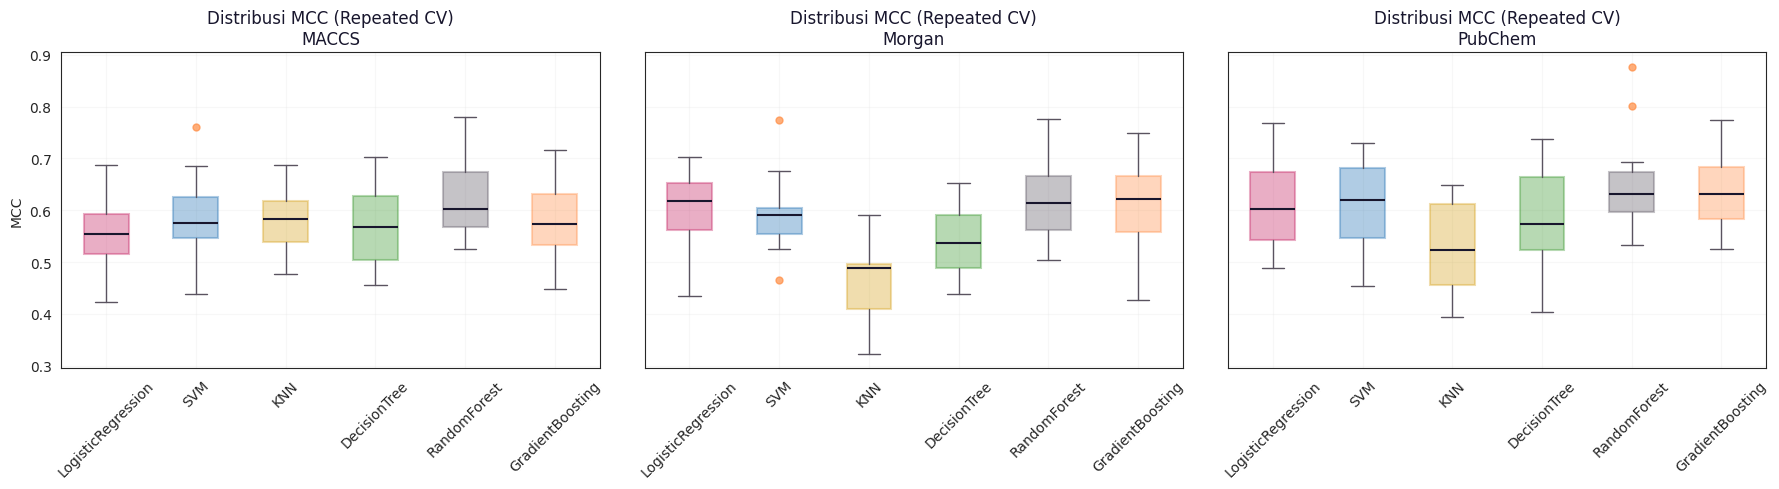

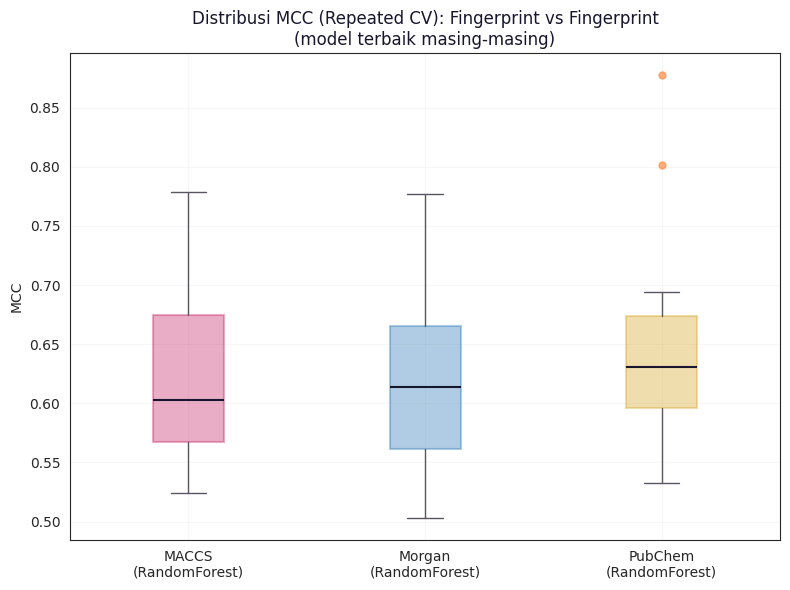


KESIMPULAN UJI STATISTIK

[MODEL vs MODEL]
  MACCS: Terdapat perbedaan performa yang SIGNIFIKAN antar model (Friedman p=0.0157 < 0.05). Lihat tabel Nemenyi_PostHoc_MACCS.xlsx untuk pasangan spesifik.
  Morgan: Terdapat perbedaan performa yang SIGNIFIKAN antar model (Friedman p=0.0000 < 0.05). Lihat tabel Nemenyi_PostHoc_Morgan.xlsx untuk pasangan spesifik.
  PubChem: Terdapat perbedaan performa yang SIGNIFIKAN antar model (Friedman p=0.0000 < 0.05). Lihat tabel Nemenyi_PostHoc_PubChem.xlsx untuk pasangan spesifik.

[FINGERPRINT vs FINGERPRINT]
  TIDAK ada cukup bukti statistik bahwa satu fingerprint lebih baik dari yang lain (Kruskal-Wallis p=0.3901 >= 0.05). Ketiga fingerprint (MACCS, Morgan, PubChem) memberikan performa yang secara statistik setara pada dataset ini.

TAHAP 12 selesai: Uji statistik model vs model dan fingerprint vs fingerprint lengkap.


In [ ]:
# ================================================================
# TAHAP 12 — UJI STATISTIK: MODEL MANA & FINGERPRINT MANA YANG
#            SECARA SIGNIFIKAN LEBIH BAIK
# ================================================================
# Tujuan: Tahap 7-11 hanya membandingkan ANGKA TITIK (rata-rata 1 kali
# CV/split). Itu BELUM cukup untuk klaim "model A lebih baik dari B"
# atau "fingerprint X lebih baik dari Y" -- perbedaan kecil bisa jadi
# cuma kebetulan dari pembagian fold/split. Tahap ini menjawab
# pertanyaan itu dengan uji statistik formal:
#
#   12.1 Bangkitkan skor MCC dari Repeated Stratified K-Fold
#        (N_REPEATS_STAT_TEST x CV_FOLDS skor per model per fingerprint)
#        -> ini DATA ULANGAN yang jadi dasar semua uji di bawah.
#
#   12.2 MODEL vs MODEL (dalam satu fingerprint, model saling
#        berpasangan pada fold yang sama):
#          - Friedman test (omnibus, non-parametrik, untuk >2 model
#            berpasangan) -> "apakah ADA perbedaan signifikan?"
#          - Nemenyi post-hoc -> "PASANGAN model mana yang beda?"
#          - Rank-biserial correlation sebagai effect size
#
#   12.3 FINGERPRINT vs FINGERPRINT (3 fingerprint, sampel TIDAK
#        berpasangan 1:1 karena jumlah baris berbeda antar fingerprint):
#          - Kruskal-Wallis test (omnibus, non-parametrik, grup independen)
#          - Mann-Whitney U berpasangan + koreksi Bonferroni -> post-hoc
#          - Cliff's Delta sebagai effect size
#
# Semua keputusan "signifikan/tidak" memakai ALPHA = 0.05.

print("="*70)
print("TAHAP 12: UJI STATISTIK MODEL & FINGERPRINT")
print("="*70)
print(f"Metode CV untuk uji: Repeated Stratified K-Fold "
      f"({N_REPEATS_STAT_TEST} repeats x {CV_FOLDS} folds = "
      f"{N_REPEATS_STAT_TEST * CV_FOLDS} skor per model/fingerprint)")
print(f"Metrik dasar uji   : MCC (Matthews Correlation Coefficient)")
print(f"Tingkat signifikansi (alpha): {ALPHA}")

# ----------------------------------------------------------------
# 12.1 BANGKITKAN SKOR MCC REPEATED CV UNTUK SETIAP (FINGERPRINT, MODEL)
# ----------------------------------------------------------------
# Catatan: dijalankan pada SELURUH data per fingerprint (bukan hanya
# X_train) supaya estimasi variansi performa lebih representatif untuk
# tujuan komparasi statistik (bukan untuk memilih model -- pemilihan
# model akhir tetap dari Tahap 8-11 yang memakai train/test split).

print("\nMenghitung skor Repeated CV (MCC) untuk setiap kombinasi fingerprint x model...")
print("(proses ini berjalan agak lama karena setiap model dilatih "
      f"{N_REPEATS_STAT_TEST * CV_FOLDS} kali per fingerprint)\n")

repeated_cv_scores = {}   # {fp_name: {model_name: array_of_mcc_scores}}

for fp_name, item in prepared_data.items():
    X = item["X"]
    y = item["y"]

    repeated_cv_scores[fp_name] = {}
    models = build_models()

    for model_name, model in models.items():
        mcc_scorer_results = cross_validate(
            model, X, y,
            cv=repeated_cv_strategy,
            scoring={"mcc": "matthews_corrcoef"},
            n_jobs=-1
        )
        scores = mcc_scorer_results["test_mcc"]
        repeated_cv_scores[fp_name][model_name] = scores
        print(f"  {fp_name:8s} | {model_name:18s} | mean MCC = {scores.mean():.4f} (sd={scores.std():.4f})")

print("\n12.1 selesai: Skor Repeated CV terkumpul untuk seluruh kombinasi.")


# ----------------------------------------------------------------
# 12.2 UJI MODEL vs MODEL (dalam satu fingerprint)
# ----------------------------------------------------------------
print("\n" + "="*70)
print("12.2 UJI STATISTIK: MODEL vs MODEL (per fingerprint)")
print("="*70)

model_stat_summary = []
nemenyi_results_all = {}

for fp_name in FINGERPRINT_FILES.keys():
    print(f"\n--- Fingerprint: {fp_name} ---")

    model_names = list(repeated_cv_scores[fp_name].keys())
    # Matriks skor: baris = fold/repeat, kolom = model (BERPASANGAN per fold)
    score_matrix = np.column_stack([repeated_cv_scores[fp_name][m] for m in model_names])

    # --- Friedman test (omnibus) ---
    friedman_stat, friedman_p = friedmanchisquare(*[score_matrix[:, i] for i in range(len(model_names))])

    is_significant = friedman_p < ALPHA
    print(f"Friedman test : statistic={friedman_stat:.4f}, p-value={friedman_p:.6f} "
          f"-> {'SIGNIFIKAN (ada perbedaan antar model)' if is_significant else 'TIDAK signifikan (model setara)'}")

    model_stat_summary.append({
        "Fingerprint": fp_name,
        "Friedman_Statistic": friedman_stat,
        "Friedman_p_value": friedman_p,
        "Signifikan": is_significant,
        "N_Models": len(model_names),
        "N_Folds": score_matrix.shape[0]
    })

    nemenyi_sig_pairs_text = []

    if is_significant:
        # --- Nemenyi post-hoc (pasangan model mana yang beda) ---
        rank_matrix = np.array([rankdata(-row) for row in score_matrix])  # rank 1 = MCC tertinggi
        pval_matrix, avg_ranks, cd = nemenyi_posthoc_test(rank_matrix)

        nemenyi_df = pd.DataFrame(pval_matrix, index=model_names, columns=model_names)
        print(f"Critical Difference (CD) Nemenyi: {cd:.4f}")
        print("Rata-rata rank tiap model (semakin kecil = semakin baik):")
        for m, r in zip(model_names, avg_ranks):
            print(f"   {m:18s} : rank rata-rata = {r:.2f}")

        display(nemenyi_df.style.format("{:.4f}") if hasattr(nemenyi_df, "style") else nemenyi_df)
        nemenyi_results_all[fp_name] = nemenyi_df
        nemenyi_df.to_excel(os.path.join(TABLE_DIR, f"Nemenyi_PostHoc_{fp_name}.xlsx"))

        # Pasangan signifikan (p < alpha)
        print("Pasangan model dengan perbedaan SIGNIFIKAN (Nemenyi p < alpha):")
        sig_pairs_found = False
        for m1, m2 in combinations(model_names, 2):
            p_val = nemenyi_df.loc[m1, m2]
            if p_val < ALPHA:
                sig_pairs_found = True
                r, magnitude = rank_biserial_from_wilcoxon(
                    repeated_cv_scores[fp_name][m1],
                    repeated_cv_scores[fp_name][m2]
                )
                winner = m1 if repeated_cv_scores[fp_name][m1].mean() > repeated_cv_scores[fp_name][m2].mean() else m2
                print(f"   {m1} vs {m2}: p={p_val:.4f} | effect size r={r:.3f} ({magnitude}) | unggul: {winner}")
                nemenyi_sig_pairs_text.append(
                    f"{m1} vs {m2} (p={p_val:.4f}, effect size {magnitude.lower()}, unggul: **{winner}**)"
                )
        if not sig_pairs_found:
            print("   (Tidak ada pasangan individual yang signifikan setelah koreksi Nemenyi,"
                  " meski Friedman omnibus signifikan -- ini mungkin terjadi pada sampel kecil.)")
    else:
        print("Karena Friedman tidak signifikan, post-hoc Nemenyi dilewati "
              "(tidak ada cukup bukti untuk klaim model tertentu lebih baik).")

    friedman_row = model_stat_summary[-1]
    interp_text = interpret_friedman_result(friedman_row, fp_name)
    if nemenyi_sig_pairs_text:
        interp_text += "\nPasangan model yang berbeda signifikan: " + "; ".join(nemenyi_sig_pairs_text) + "."
    elif is_significant:
        interp_text += (
            "\nNamun, tidak ada pasangan INDIVIDUAL yang lolos koreksi Nemenyi -- ini bisa terjadi "
            "ketika perbedaan tersebar di banyak model sekaligus, bukan terkonsentrasi pada 1-2 "
            "pasangan tertentu (umum pada sampel kecil dengan banyak model dibandingkan)."
        )
    log_interpretation(tahap="12", judul=f"Friedman Test — {fp_name}", narasi=interp_text, print_now=False)

model_stat_summary_df = pd.DataFrame(model_stat_summary)
display(model_stat_summary_df)
model_stat_summary_df.to_excel(os.path.join(TABLE_DIR, "Statistical_Test_Model_vs_Model.xlsx"), index=False)

print("\n12.2 selesai: Uji model vs model per fingerprint selesai.")


# ----------------------------------------------------------------
# 12.3 UJI FINGERPRINT vs FINGERPRINT
# ----------------------------------------------------------------
print("\n" + "="*70)
print("12.3 UJI STATISTIK: FINGERPRINT vs FINGERPRINT")
print("="*70)
print("Catatan metodologis: sampel antar fingerprint TIDAK berpasangan 1:1")
print("(jumlah baris bisa berbeda, representasi fitur berbeda) -> dipakai")
print("uji untuk GRUP INDEPENDEN (Kruskal-Wallis), bukan Friedman/Wilcoxon.\n")

# Untuk tiap fingerprint, ambil skor repeated-CV dari MODEL TERBAIKNYA
# (berdasarkan best_per_fp dari Tahap 8) sebagai representasi fingerprint
# tersebut -- perbandingan "fingerprint terbaik vs fingerprint terbaik".
best_model_per_fp_for_stat = dict(zip(best_per_fp["Fingerprint"], best_per_fp["Model"]))

print("Model representatif yang dipakai per fingerprint (model terbaik versi Tahap 8):")
for fp_name, model_name in best_model_per_fp_for_stat.items():
    print(f"   {fp_name:8s} -> {model_name}")

fp_score_groups = {
    fp_name: repeated_cv_scores[fp_name][model_name]
    for fp_name, model_name in best_model_per_fp_for_stat.items()
}

# --- Kruskal-Wallis test (omnibus) ---
kw_stat, kw_p = kruskal(*fp_score_groups.values())
kw_significant = kw_p < ALPHA

print(f"\nKruskal-Wallis test : statistic={kw_stat:.4f}, p-value={kw_p:.6f} "
      f"-> {'SIGNIFIKAN (ada perbedaan antar fingerprint)' if kw_significant else 'TIDAK signifikan (fingerprint setara)'}")

fingerprint_stat_summary = [{
    "Test": "Kruskal-Wallis (omnibus)",
    "Statistic": kw_stat,
    "p_value": kw_p,
    "Signifikan": kw_significant
}]

fp_pairwise_results = []

if kw_significant:
    fp_names_list = list(fp_score_groups.keys())
    n_comparisons = len(list(combinations(fp_names_list, 2)))
    bonferroni_alpha = ALPHA / n_comparisons   # koreksi Bonferroni untuk multiple comparison

    print(f"\nPost-hoc Mann-Whitney U (koreksi Bonferroni, alpha disesuaikan = {bonferroni_alpha:.4f}):")

    for fp1, fp2 in combinations(fp_names_list, 2):
        scores_1 = fp_score_groups[fp1]
        scores_2 = fp_score_groups[fp2]

        u_stat, u_p = mannwhitneyu(scores_1, scores_2, alternative="two-sided")
        delta, magnitude = cliffs_delta(scores_1, scores_2)

        is_sig_after_correction = u_p < bonferroni_alpha
        winner = fp1 if scores_1.mean() > scores_2.mean() else fp2

        print(f"   {fp1} vs {fp2}: p={u_p:.4f} | Cliff's delta={delta:.3f} ({magnitude}) "
              f"| {'SIGNIFIKAN' if is_sig_after_correction else 'tidak signifikan'} "
              f"| unggul (rata-rata): {winner}")

        fp_pairwise_results.append({
            "Fingerprint_1": fp1,
            "Fingerprint_2": fp2,
            "Mean_MCC_1": scores_1.mean(),
            "Mean_MCC_2": scores_2.mean(),
            "Mann_Whitney_U": u_stat,
            "p_value": u_p,
            "Bonferroni_alpha": bonferroni_alpha,
            "Signifikan_setelah_koreksi": is_sig_after_correction,
            "Cliffs_Delta": delta,
            "Effect_Size_Magnitude": magnitude,
            "Fingerprint_Unggul": winner
        })
else:
    print("Karena Kruskal-Wallis tidak signifikan, post-hoc Mann-Whitney dilewati "
          "(tidak ada cukup bukti untuk klaim fingerprint tertentu lebih baik).")

fingerprint_stat_summary_df = pd.DataFrame(fingerprint_stat_summary)
display(fingerprint_stat_summary_df)
fingerprint_stat_summary_df.to_excel(os.path.join(TABLE_DIR, "Statistical_Test_Fingerprint_Omnibus.xlsx"), index=False)

kw_interp_text = interpret_kruskal_result(kw_p, kw_significant, fp_score_groups)

if fp_pairwise_results:
    fp_pairwise_df = pd.DataFrame(fp_pairwise_results)
    display(fp_pairwise_df)
    fp_pairwise_df.to_excel(os.path.join(TABLE_DIR, "Statistical_Test_Fingerprint_Pairwise.xlsx"), index=False)

    sig_fp_pairs = fp_pairwise_df[fp_pairwise_df["Signifikan_setelah_koreksi"]]
    if len(sig_fp_pairs) > 0:
        pairs_text = "; ".join(
            f"{r['Fingerprint_1']} vs {r['Fingerprint_2']} (p={r['p_value']:.4f}, "
            f"{r['Effect_Size_Magnitude'].lower()}, unggul: **{r['Fingerprint_Unggul']}**)"
            for _, r in sig_fp_pairs.iterrows()
        )
        kw_interp_text += f"\nPasangan fingerprint yang berbeda signifikan (setelah Bonferroni): {pairs_text}."
    else:
        kw_interp_text += (
            "\nNamun, tidak ada pasangan INDIVIDUAL yang lolos koreksi Bonferroni -- perbedaan "
            "yang terdeteksi Kruskal-Wallis kemungkinan tersebar tipis di ketiga fingerprint, "
            "bukan terkonsentrasi pada 1 pasangan tertentu."
        )

log_interpretation(
    tahap="12",
    judul="Kruskal-Wallis Test — Fingerprint vs Fingerprint",
    narasi=kw_interp_text
)

print("\n12.3 selesai: Uji fingerprint vs fingerprint selesai.")


# ----------------------------------------------------------------
# 12.4 VISUALISASI: BOXPLOT DISTRIBUSI SKOR REPEATED CV
# ----------------------------------------------------------------
# Boxplot memperlihatkan SEBARAN skor (bukan cuma rata-rata), supaya
# terlihat jelas tumpang-tindih (overlap) yang menjelaskan signifikansi.

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, fp_name in enumerate(FINGERPRINT_FILES.keys()):
    model_names = list(repeated_cv_scores[fp_name].keys())
    data_to_plot = [repeated_cv_scores[fp_name][m] for m in model_names]

    bp = axes[idx].boxplot(data_to_plot, labels=model_names, patch_artist=True)
    style_boxplot(bp)
    axes[idx].set_title(f"Distribusi MCC (Repeated CV)\n{fp_name}")
    axes[idx].set_ylabel("MCC" if idx == 0 else "")
    axes[idx].tick_params(axis="x", rotation=45)
    axes[idx].grid(True, alpha=0.3, color=project_colors["grid"])

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "Statistical_Test_Model_Boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()

# Boxplot fingerprint vs fingerprint (model terbaik masing-masing)
plt.figure(figsize=(8, 6))
fp_labels = [f"{fp}\n({best_model_per_fp_for_stat[fp]})" for fp in fp_score_groups.keys()]
fp_palette = [FINGERPRINT_COLOR_MAP[fp] for fp in fp_score_groups.keys()]
bp_fp = plt.boxplot(list(fp_score_groups.values()), labels=fp_labels, patch_artist=True)
style_boxplot(bp_fp, palette=fp_palette)
plt.ylabel("MCC")
plt.title("Distribusi MCC (Repeated CV): Fingerprint vs Fingerprint\n(model terbaik masing-masing)")
plt.grid(True, alpha=0.3, color=project_colors["grid"])
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "Statistical_Test_Fingerprint_Boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()


# ----------------------------------------------------------------
# 12.5 KESIMPULAN NARATIF (otomatis, berdasarkan hasil uji di atas)
# ----------------------------------------------------------------
print("\n" + "="*70)
print("KESIMPULAN UJI STATISTIK")
print("="*70)

print("\n[MODEL vs MODEL]")
for _, row in model_stat_summary_df.iterrows():
    fp_name = row["Fingerprint"]
    if row["Signifikan"]:
        print(f"  {fp_name}: Terdapat perbedaan performa yang SIGNIFIKAN antar model "
              f"(Friedman p={row['Friedman_p_value']:.4f} < {ALPHA}). "
              f"Lihat tabel Nemenyi_PostHoc_{fp_name}.xlsx untuk pasangan spesifik.")
    else:
        print(f"  {fp_name}: TIDAK ada cukup bukti statistik bahwa satu model lebih baik dari "
              f"yang lain (Friedman p={row['Friedman_p_value']:.4f} >= {ALPHA}). "
              f"Perbedaan rata-rata MCC yang terlihat sebelumnya bisa jadi hanya kebetulan.")

print("\n[FINGERPRINT vs FINGERPRINT]")
if kw_significant:
    print(f"  Terdapat perbedaan performa yang SIGNIFIKAN antar fingerprint "
          f"(Kruskal-Wallis p={kw_p:.4f} < {ALPHA}).")
    best_fp_by_mean = max(fp_score_groups, key=lambda k: fp_score_groups[k].mean())
    print(f"  Fingerprint dengan rata-rata MCC tertinggi: {best_fp_by_mean} "
          f"(MCC={fp_score_groups[best_fp_by_mean].mean():.4f})")
    print("  Lihat Statistical_Test_Fingerprint_Pairwise.xlsx untuk pasangan mana yang signifikan.")
else:
    print(f"  TIDAK ada cukup bukti statistik bahwa satu fingerprint lebih baik dari yang lain "
          f"(Kruskal-Wallis p={kw_p:.4f} >= {ALPHA}). Ketiga fingerprint (MACCS, Morgan, PubChem) "
          f"memberikan performa yang secara statistik setara pada dataset ini.")

print("\nTAHAP 12 selesai: Uji statistik model vs model dan fingerprint vs fingerprint lengkap.")


TAHAP 13: VALIDITAS KESELURUHAN PROSES MODELING
Target analisis: PubChem - RandomForest (Baseline)

--- 13.1 Data Leakage Check ---
Memeriksa apakah scaler/preprocessing di-fit SEBELUM atau SESUDAH split...
  - Model RandomForest tidak memakai scaler (tree-based model: Decision Tree/Random Forest/Gradient Boosting tidak sensitif terhadap skala fitur, jadi scaler memang tidak diperlukan) -> tidak relevan untuk leakage scaling.
  - CATATAN: penghapusan fitur konstan (Tahap 5) dihitung dari SELURUH data (termasuk yang nanti masuk test set). Ini leakage RINGAN dan UMUM diterima dalam praktik (karena tidak melibatkan label/y, hanya variance fitur), tapi secara ketat sebaiknya dihitung hanya dari data train jika ingin 100% murni.

--- 13.2 Stabilitas Multi-Seed (10 seed berbeda) ---
Mengulang train/test split dengan random_state berbeda untuk melihat
apakah performa model final stabil atau berubah drastis karena kebetulan split.



,Seed,MCC,F1
0,0,0.624306,0.841314
1,1,0.572540,0.813678
2,2,0.708683,0.874818
3,3,0.659932,0.853954
4,4,0.638397,0.845053
5,5,0.442634,0.765701
6,6,0.708683,0.874818
7,7,0.736635,0.885711
8,8,0.582323,0.821886
9,9,0.798573,0.914914


MCC across 10 seeds: mean=0.6473, std=0.1005, range=0.3559 (min=0.4426, max=0.7986)
STATUS: TIDAK STABIL -> rentang MCC antar seed (0.3559) > ambang (0.15). Performa sangat dipengaruhi pembagian data; sebaiknya selalu acu ke hasil Cross-Val Predict/Repeated CV (Tahap 11 & 12), BUKAN ke satu angka dari single-split.


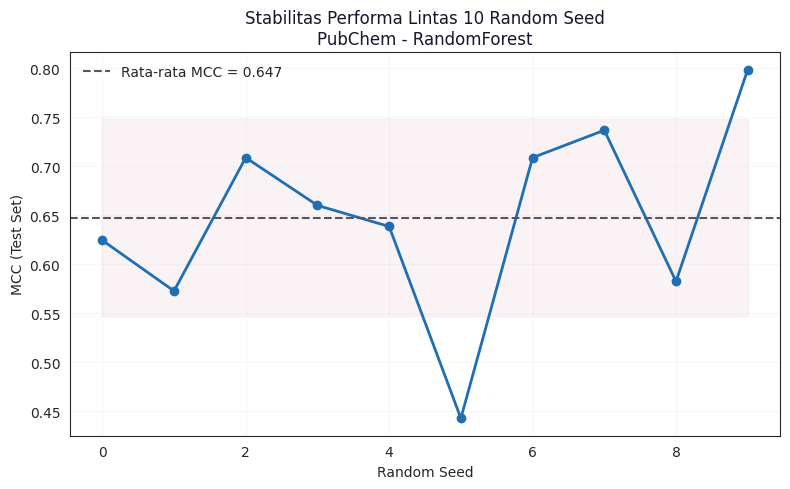


--- 13.3 Overfitting Gap (Train vs Cross-Validation) ---
MCC pada data TRAIN (rata-rata 5 fold): 0.9718
MCC pada data VALIDATION/CV (rata-rata 5 fold): 0.6558
Overfitting Gap (Train - CV): 0.3161
STATUS: INDIKASI OVERFITTING -> gap (0.3161) > ambang (0.15). Model menghafal data train, performa pada data baru kemungkinan lebih rendah dari yang terlihat. Pertimbangkan: kurangi kompleksitas model (max_depth, n_estimators), tambah regularisasi, atau tambah data.

--- 13.4 Learning Curve ---
Melihat apakah performa masih akan naik dengan data lebih banyak,
atau sudah mendatar (plateau) -- penanda apakah data sudah 'cukup'.



,Train_Size,Train_MCC,Val_MCC,Val_MCC_Std
0,76,1.000000,0.547268,0.071076
1,136,0.990021,0.548654,0.088326
2,197,0.970812,0.587096,0.109028
3,258,0.969825,0.582390,0.092015
4,319,0.975022,0.603034,0.077419
5,380,0.971845,0.655759,0.075464


Kenaikan MCC validasi dari setengah data terakhir ke 100% data: +0.0734
STATUS: MASIH NAIK -> kurva validasi masih meningkat seiring jumlah data. Menambah lebih banyak sampel (senyawa) kemungkinan akan meningkatkan performa lebih jauh.


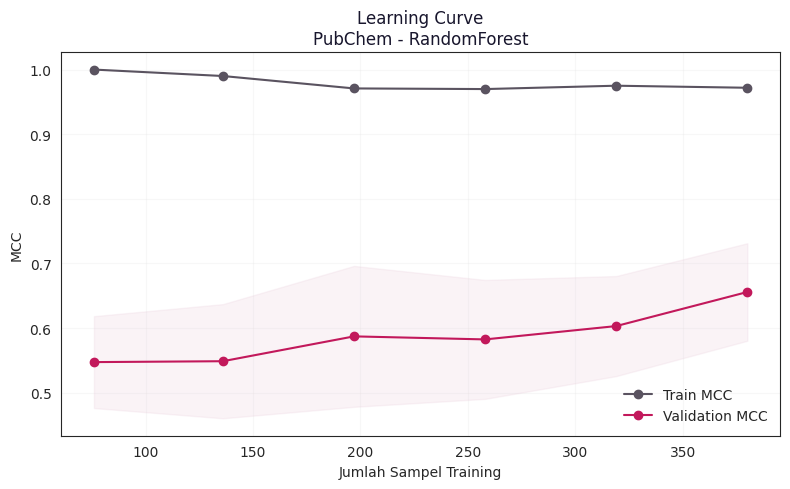


--- 13.5 Variance Antar Fold (Konsistensi Cross-Validation) ---
MCC across 25 repeated-CV folds: mean=0.6427, std=0.0730
Coefficient of Variation (std/|mean|): 0.1135
STATUS: KONSISTEN -> variabilitas antar fold relatif kecil dibanding rata-ratanya, model memberikan performa yang dapat diandalkan di berbagai subset data.


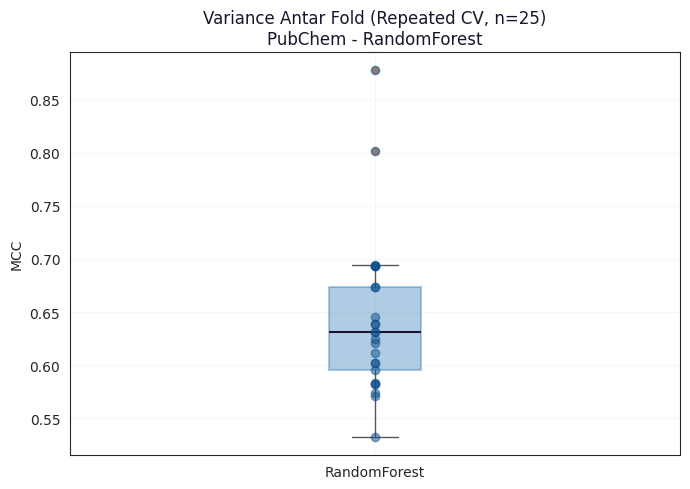


--- 13.6 Dummy Baseline Check ---
Membandingkan model final dengan classifier paling dasar (asal tebak),
untuk memastikan model benar-benar belajar sesuatu, bukan cuma menebak kelas mayoritas.



,Strategy,MCC,F1_Weighted
0,most_frequent,0.000000,0.566863
1,stratified,-0.050166,0.551160
2,uniform,-0.109317,0.451852


MCC model final (RandomForest): 0.6427
MCC dummy classifier terbaik: 0.0000
STATUS: LOLOS -> model final (0.6427) jauh lebih baik dari dummy classifier terbaik (0.0000). Model terbukti belajar pola yang nyata, bukan sekadar menebak kelas mayoritas.

RINGKASAN VALIDITAS KESELURUHAN PROSES MODELING


,Check,Status,Detail
0,13.1 Data Leakage (Scaling),AMAN (tidak relevan),Model RandomForest tidak memakai scaler (tree-...
1,13.1 Data Leakage (Feature Selection),"PERHATIAN (leakage ringan, umum diterima)",CATATAN: penghapusan fitur konstan (Tahap 5) d...
2,13.2 Stabilitas Multi-Seed,TIDAK STABIL,MCC range across 10 seeds = 0.3559 (mean=0.647...
3,13.3 Overfitting Gap,INDIKASI OVERFITTING,"Train MCC=0.9718, CV MCC=0.6558, Gap=0.3161"
4,13.4 Learning Curve,MASIH NAIK (data lebih banyak bisa membantu),Slope paruh akhir kurva validasi = +0.0734
5,13.5 Variance Antar Fold,KONSISTEN,"Mean MCC=0.6427, Std=0.0730, CV=0.1135"
6,13.6 Dummy Baseline Check,LOLOS,Model MCC=0.6427 vs Best Dummy MCC=0.0000 (sel...


  [AMAN (tidak relevan)] 13.1 Data Leakage (Scaling)
      -> Model RandomForest tidak memakai scaler (tree-based model: Decision Tree/Random Forest/Gradient Boosting tidak sensitif terhadap skala fitur, jadi scaler memang tidak diperlukan) -> tidak relevan untuk leakage scaling.
  [PERHATIAN (leakage ringan, umum diterima)] 13.1 Data Leakage (Feature Selection)
      -> CATATAN: penghapusan fitur konstan (Tahap 5) dihitung dari SELURUH data (termasuk yang nanti masuk test set). Ini leakage RINGAN dan UMUM diterima dalam praktik (karena tidak melibatkan label/y, hanya variance fitur), tapi secara ketat sebaiknya dihitung hanya dari data train jika ingin 100% murni.
  [TIDAK STABIL] 13.2 Stabilitas Multi-Seed
      -> MCC range across 10 seeds = 0.3559 (mean=0.6473, std=0.1005)
  [INDIKASI OVERFITTING] 13.3 Overfitting Gap
      -> Train MCC=0.9718, CV MCC=0.6558, Gap=0.3161
  [MASIH NAIK (data lebih banyak bisa membantu)] 13.4 Learning Curve
      -> Slope paruh akhir kurva validasi = 

In [ ]:
# ================================================================
# TAHAP 13 — VALIDITAS KESELURUHAN PROSES MODELING
# ================================================================
# Tujuan: menjawab pertanyaan "apakah seluruh proses modeling ini VALID",
# bukan cuma "model mana yang menang". Mencakup 6 pengecekan standar:
#
#   13.1 Data Leakage Check    -> apakah scaling/preprocessing terjadi
#                                  SEBELUM split (bocor) atau SESUDAH (benar)?
#   13.2 Stabilitas Multi-Seed -> apakah hasil robust kalau random_state
#                                  diganti, atau cuma untung-untungan satu seed?
#   13.3 Overfitting Gap       -> apakah skor Train >> skor CV (overfit)?
#   13.4 Learning Curve        -> apakah performa masih naik dengan data
#                                  lebih banyak, atau sudah mendatar (plateau)?
#   13.5 Variance Antar Fold   -> apakah model konsisten antar fold CV,
#                                  atau std antar fold besar (tidak stabil)?
#   13.6 Dummy Baseline Check  -> apakah model benar-benar lebih baik dari
#                                  classifier paling dasar (sanity check)?
#
# Dijalankan untuk MODEL FINAL TERPILIH (final_fp, final_model_name) saja,
# supaya fokus dan tidak mengulang seluruh kombinasi model x fingerprint.

print("="*70)
print("TAHAP 13: VALIDITAS KESELURUHAN PROSES MODELING")
print(f"Target analisis: {final_fp} - {final_model_name} ({stage_label})")
print("="*70)

validity_summary = []   # akan jadi 1 tabel rekap akhir, kolom: Check, Status, Detail

# ----------------------------------------------------------------
# 13.1 DATA LEAKAGE CHECK
# ----------------------------------------------------------------
print("\n--- 13.1 Data Leakage Check ---")
print("Memeriksa apakah scaler/preprocessing di-fit SEBELUM atau SESUDAH split...")

leakage_notes = []
core_check_model = final_model.named_steps["model"] if hasattr(final_model, "named_steps") else final_model

if hasattr(final_model, "named_steps") and "scaler" in final_model.named_steps:
    leakage_notes.append(
        "Model memakai sklearn Pipeline (scaler + model). Karena cross_validate/"
        "cross_val_predict/GridSearchCV menerima OBJEK PIPELINE (bukan data yang "
        "sudah di-scale duluan), scaler di-fit ULANG pada setiap fold train secara "
        "otomatis oleh sklearn -> TIDAK ADA data leakage dari scaling."
    )
    leakage_status = "AMAN"
else:
    leakage_notes.append(
        f"Model {final_model_name} tidak memakai scaler (tree-based model: "
        "Decision Tree/Random Forest/Gradient Boosting tidak sensitif terhadap skala "
        "fitur, jadi scaler memang tidak diperlukan) -> tidak relevan untuk leakage scaling."
    )
    leakage_status = "AMAN (tidak relevan)"

# Cek tambahan: pastikan fitur konstan dibuang SEBELUM split (Tahap 5), bukan
# berdasarkan informasi dari test set -- variance dihitung dari SELURUH data,
# yang secara ketat juga merupakan bentuk leakage ringan (label tidak terlibat,
# tapi distribusi fitur test "terlihat" saat memutuskan fitur mana yang dibuang).
leakage_notes.append(
    "CATATAN: penghapusan fitur konstan (Tahap 5) dihitung dari SELURUH data "
    "(termasuk yang nanti masuk test set). Ini leakage RINGAN dan UMUM diterima "
    "dalam praktik (karena tidak melibatkan label/y, hanya variance fitur), tapi "
    "secara ketat sebaiknya dihitung hanya dari data train jika ingin 100% murni."
)

for note in leakage_notes:
    print(f"  - {note}")

validity_summary.append({
    "Check": "13.1 Data Leakage (Scaling)",
    "Status": leakage_status,
    "Detail": leakage_notes[0]
})
validity_summary.append({
    "Check": "13.1 Data Leakage (Feature Selection)",
    "Status": "PERHATIAN (leakage ringan, umum diterima)",
    "Detail": leakage_notes[1]
})

# ----------------------------------------------------------------
# 13.2 STABILITAS MULTI-SEED
# ----------------------------------------------------------------
print(f"\n--- 13.2 Stabilitas Multi-Seed ({N_SEEDS_STABILITY_CHECK} seed berbeda) ---")
print("Mengulang train/test split dengan random_state berbeda untuk melihat")
print("apakah performa model final stabil atau berubah drastis karena kebetulan split.\n")

X_stab = prepared_data[final_fp]["X"]
y_stab = prepared_data[final_fp]["y"]

stability_scores = []
for seed in SEEDS_TO_TEST:
    Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
        X_stab, y_stab, test_size=TEST_SIZE, stratify=y_stab, random_state=seed
    )
    model_seed = final_model.__class__(**final_model.get_params()) if not hasattr(final_model, "named_steps") \
        else Pipeline([(name, step.__class__(**step.get_params())) for name, step in final_model.named_steps.items()])
    model_seed.fit(Xtr_s, ytr_s)
    pred_seed = model_seed.predict(Xte_s)
    mcc_seed = matthews_corrcoef(yte_s, pred_seed)
    f1_seed = f1_score(yte_s, pred_seed, average="weighted")
    stability_scores.append({"Seed": seed, "MCC": mcc_seed, "F1": f1_seed})

stability_df = pd.DataFrame(stability_scores)
display(stability_df)
stability_df.to_excel(os.path.join(TABLE_DIR, "Validity_MultiSeed_Stability.xlsx"), index=False)

mcc_mean = stability_df["MCC"].mean()
mcc_std = stability_df["MCC"].std()
mcc_range = stability_df["MCC"].max() - stability_df["MCC"].min()

print(f"MCC across {N_SEEDS_STABILITY_CHECK} seeds: mean={mcc_mean:.4f}, std={mcc_std:.4f}, "
      f"range={mcc_range:.4f} (min={stability_df['MCC'].min():.4f}, max={stability_df['MCC'].max():.4f})")

is_stable = mcc_range <= STABILITY_GAP_WARN_THRESHOLD
if is_stable:
    print(f"STATUS: STABIL -> rentang MCC antar seed ({mcc_range:.4f}) <= ambang "
          f"({STABILITY_GAP_WARN_THRESHOLD}). Hasil single-split sebelumnya cukup dapat dipercaya.")
else:
    print(f"STATUS: TIDAK STABIL -> rentang MCC antar seed ({mcc_range:.4f}) > ambang "
          f"({STABILITY_GAP_WARN_THRESHOLD}). Performa sangat dipengaruhi pembagian data; "
          f"sebaiknya selalu acu ke hasil Cross-Val Predict/Repeated CV (Tahap 11 & 12), "
          f"BUKAN ke satu angka dari single-split.")

plt.figure(figsize=(8, 5))
plt.plot(stability_df["Seed"], stability_df["MCC"], marker="o", linewidth=2, color=project_colors["down"])
plt.axhline(mcc_mean, color=project_colors["ns_dark"], linestyle="--", label=f"Rata-rata MCC = {mcc_mean:.3f}")
plt.fill_between(stability_df["Seed"], mcc_mean - mcc_std, mcc_mean + mcc_std,
                  alpha=0.2, color=project_colors["strip"])
plt.xlabel("Random Seed")
plt.ylabel("MCC (Test Set)")
plt.title(f"Stabilitas Performa Lintas {N_SEEDS_STABILITY_CHECK} Random Seed\n{final_fp} - {final_model_name}")
plt.legend()
plt.grid(True, alpha=0.3, color=project_colors["grid"])
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "Validity_MultiSeed_Stability.png"), dpi=300)
plt.show()

validity_summary.append({
    "Check": "13.2 Stabilitas Multi-Seed",
    "Status": "STABIL" if is_stable else "TIDAK STABIL",
    "Detail": f"MCC range across {N_SEEDS_STABILITY_CHECK} seeds = {mcc_range:.4f} "
              f"(mean={mcc_mean:.4f}, std={mcc_std:.4f})"
})

# ----------------------------------------------------------------
# 13.3 OVERFITTING GAP (Train Score vs CV Score)
# ----------------------------------------------------------------
print("\n--- 13.3 Overfitting Gap (Train vs Cross-Validation) ---")

model_overfit_check = final_model.__class__(**final_model.get_params()) if not hasattr(final_model, "named_steps") \
    else Pipeline([(name, step.__class__(**step.get_params())) for name, step in final_model.named_steps.items()])

overfit_cv = cross_validate(
    model_overfit_check, X_stab, y_stab,
    cv=cv_strategy,
    scoring={"mcc": "matthews_corrcoef"},
    return_train_score=True,
    n_jobs=-1
)

train_score_mean = overfit_cv["train_mcc"].mean()
cv_score_mean = overfit_cv["test_mcc"].mean()
overfit_gap = train_score_mean - cv_score_mean

print(f"MCC pada data TRAIN (rata-rata {CV_FOLDS} fold): {train_score_mean:.4f}")
print(f"MCC pada data VALIDATION/CV (rata-rata {CV_FOLDS} fold): {cv_score_mean:.4f}")
print(f"Overfitting Gap (Train - CV): {overfit_gap:.4f}")

is_overfitting = overfit_gap > OVERFIT_GAP_WARN_THRESHOLD
if is_overfitting:
    print(f"STATUS: INDIKASI OVERFITTING -> gap ({overfit_gap:.4f}) > ambang "
          f"({OVERFIT_GAP_WARN_THRESHOLD}). Model menghafal data train, performa pada "
          f"data baru kemungkinan lebih rendah dari yang terlihat. Pertimbangkan: "
          f"kurangi kompleksitas model (max_depth, n_estimators), tambah regularisasi, "
          f"atau tambah data.")
else:
    print(f"STATUS: GAP WAJAR -> ({overfit_gap:.4f}) <= ambang ({OVERFIT_GAP_WARN_THRESHOLD}). "
          f"Tidak ada indikasi overfitting yang mengkhawatirkan.")

validity_summary.append({
    "Check": "13.3 Overfitting Gap",
    "Status": "INDIKASI OVERFITTING" if is_overfitting else "WAJAR",
    "Detail": f"Train MCC={train_score_mean:.4f}, CV MCC={cv_score_mean:.4f}, Gap={overfit_gap:.4f}"
})

# ----------------------------------------------------------------
# 13.4 LEARNING CURVE
# ----------------------------------------------------------------
print("\n--- 13.4 Learning Curve ---")
print("Melihat apakah performa masih akan naik dengan data lebih banyak,")
print("atau sudah mendatar (plateau) -- penanda apakah data sudah 'cukup'.\n")

model_lc_check = final_model.__class__(**final_model.get_params()) if not hasattr(final_model, "named_steps") \
    else Pipeline([(name, step.__class__(**step.get_params())) for name, step in final_model.named_steps.items()])

train_sizes_abs, train_scores_lc, val_scores_lc = learning_curve(
    model_lc_check, X_stab, y_stab,
    train_sizes=LEARNING_CURVE_TRAIN_SIZES,
    cv=cv_strategy,
    scoring="matthews_corrcoef",
    n_jobs=-1
)

train_scores_mean_lc = train_scores_lc.mean(axis=1)
val_scores_mean_lc = val_scores_lc.mean(axis=1)
val_scores_std_lc = val_scores_lc.std(axis=1)

learning_curve_df = pd.DataFrame({
    "Train_Size": train_sizes_abs,
    "Train_MCC": train_scores_mean_lc,
    "Val_MCC": val_scores_mean_lc,
    "Val_MCC_Std": val_scores_std_lc
})
display(learning_curve_df)
learning_curve_df.to_excel(os.path.join(TABLE_DIR, "Validity_Learning_Curve.xlsx"), index=False)

# Indikasi plateau: selisih val_score antara 60% dan 100% data terakhir kecil
val_at_60pct_idx = len(val_scores_mean_lc) // 2
slope_last_half = val_scores_mean_lc[-1] - val_scores_mean_lc[val_at_60pct_idx]
is_plateau = abs(slope_last_half) < 0.03

print(f"Kenaikan MCC validasi dari setengah data terakhir ke 100% data: {slope_last_half:+.4f}")
if is_plateau:
    print("STATUS: PLATEAU -> menambah data tampaknya TIDAK akan banyak menaikkan performa "
          "(kurva sudah mendatar). Performa saat ini cukup mewakili kapasitas model pada "
          "data berkarakteristik serupa.")
else:
    print("STATUS: MASIH NAIK -> kurva validasi masih meningkat seiring jumlah data. "
          "Menambah lebih banyak sampel (senyawa) kemungkinan akan meningkatkan performa lebih jauh.")

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_abs, train_scores_mean_lc, marker="o", label="Train MCC", color=project_colors["ns_dark"])
plt.plot(train_sizes_abs, val_scores_mean_lc, marker="o", label="Validation MCC", color=project_colors["up"])
plt.fill_between(train_sizes_abs, val_scores_mean_lc - val_scores_std_lc,
                  val_scores_mean_lc + val_scores_std_lc, alpha=0.2, color=project_colors["strip"])
plt.xlabel("Jumlah Sampel Training")
plt.ylabel("MCC")
plt.title(f"Learning Curve\n{final_fp} - {final_model_name}")
plt.legend()
plt.grid(True, alpha=0.3, color=project_colors["grid"])
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "Validity_Learning_Curve.png"), dpi=300)
plt.show()

validity_summary.append({
    "Check": "13.4 Learning Curve",
    "Status": "PLATEAU (data cukup)" if is_plateau else "MASIH NAIK (data lebih banyak bisa membantu)",
    "Detail": f"Slope paruh akhir kurva validasi = {slope_last_half:+.4f}"
})

# ----------------------------------------------------------------
# 13.5 VARIANCE ANTAR FOLD (konsistensi CV)
# ----------------------------------------------------------------
print("\n--- 13.5 Variance Antar Fold (Konsistensi Cross-Validation) ---")

fold_scores = repeated_cv_scores[final_fp][final_model_name]  # sudah dihitung di Tahap 12.1 (25 skor)
fold_mean = fold_scores.mean()
fold_std = fold_scores.std()
fold_cv_coefficient = fold_std / abs(fold_mean) if fold_mean != 0 else np.inf

print(f"MCC across {len(fold_scores)} repeated-CV folds: mean={fold_mean:.4f}, std={fold_std:.4f}")
print(f"Coefficient of Variation (std/|mean|): {fold_cv_coefficient:.4f}")

is_consistent = fold_cv_coefficient < 0.5
if is_consistent:
    print("STATUS: KONSISTEN -> variabilitas antar fold relatif kecil dibanding rata-ratanya, "
          "model memberikan performa yang dapat diandalkan di berbagai subset data.")
else:
    print("STATUS: KURANG KONSISTEN -> variabilitas antar fold cukup besar dibanding rata-ratanya. "
          "Performa model bisa naik-turun cukup signifikan tergantung subset data yang dipakai; "
          "kemungkinan terkait ukuran sampel yang masih kecil/imbalanced.")

plt.figure(figsize=(7, 5))
bp_fold = plt.boxplot(fold_scores, vert=True, patch_artist=True)
style_boxplot(bp_fold, palette=[project_colors["down"]])
plt.scatter([1] * len(fold_scores), fold_scores, alpha=0.5, color=project_colors["down_dark"], zorder=3)
plt.ylabel("MCC")
plt.title(f"Variance Antar Fold (Repeated CV, n={len(fold_scores)})\n{final_fp} - {final_model_name}")
plt.xticks([1], [final_model_name])
plt.grid(True, alpha=0.3, color=project_colors["grid"])
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "Validity_Fold_Variance.png"), dpi=300)
plt.show()

validity_summary.append({
    "Check": "13.5 Variance Antar Fold",
    "Status": "KONSISTEN" if is_consistent else "KURANG KONSISTEN",
    "Detail": f"Mean MCC={fold_mean:.4f}, Std={fold_std:.4f}, CV={fold_cv_coefficient:.4f}"
})

# ----------------------------------------------------------------
# 13.6 DUMMY BASELINE CHECK (sanity check paling dasar)
# ----------------------------------------------------------------
print("\n--- 13.6 Dummy Baseline Check ---")
print("Membandingkan model final dengan classifier paling dasar (asal tebak),")
print("untuk memastikan model benar-benar belajar sesuatu, bukan cuma menebak kelas mayoritas.\n")

dummy_strategies = ["most_frequent", "stratified", "uniform"]
dummy_results = []

for strategy in dummy_strategies:
    dummy_model = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy_cv = cross_validate(
        dummy_model, X_stab, y_stab,
        cv=cv_strategy,
        scoring={"mcc": "matthews_corrcoef", "f1": "f1_weighted"},
        n_jobs=-1
    )
    dummy_results.append({
        "Strategy": strategy,
        "MCC": dummy_cv["test_mcc"].mean(),
        "F1_Weighted": dummy_cv["test_f1"].mean()
    })

dummy_df = pd.DataFrame(dummy_results)
display(dummy_df)
dummy_df.to_excel(os.path.join(TABLE_DIR, "Validity_Dummy_Baseline.xlsx"), index=False)

final_model_cv_mcc = repeated_cv_scores[final_fp][final_model_name].mean()
best_dummy_mcc = dummy_df["MCC"].max()

print(f"MCC model final ({final_model_name}): {final_model_cv_mcc:.4f}")
print(f"MCC dummy classifier terbaik: {best_dummy_mcc:.4f}")

beats_dummy = final_model_cv_mcc > best_dummy_mcc + 0.05  # margin kecil supaya tidak cuma "sedikit lebih baik"
if beats_dummy:
    print(f"STATUS: LOLOS -> model final ({final_model_cv_mcc:.4f}) jauh lebih baik dari dummy "
          f"classifier terbaik ({best_dummy_mcc:.4f}). Model terbukti belajar pola yang nyata, "
          f"bukan sekadar menebak kelas mayoritas.")
else:
    print(f"STATUS: PERLU PERHATIAN -> selisih model final dengan dummy classifier kecil "
          f"({final_model_cv_mcc - best_dummy_mcc:.4f}). Pertimbangkan: data mungkin kurang "
          f"informatif untuk memprediksi binding affinity dengan threshold saat ini, atau "
          f"fitur/fingerprint yang dipakai belum cukup menangkap pola yang relevan.")

validity_summary.append({
    "Check": "13.6 Dummy Baseline Check",
    "Status": "LOLOS" if beats_dummy else "PERLU PERHATIAN",
    "Detail": f"Model MCC={final_model_cv_mcc:.4f} vs Best Dummy MCC={best_dummy_mcc:.4f} "
              f"(selisih={final_model_cv_mcc - best_dummy_mcc:.4f})"
})

# ----------------------------------------------------------------
# 13.7 RINGKASAN VALIDITAS KESELURUHAN
# ----------------------------------------------------------------
print("\n" + "="*70)
print("RINGKASAN VALIDITAS KESELURUHAN PROSES MODELING")
print("="*70)

validity_summary_df = pd.DataFrame(validity_summary)
display(validity_summary_df)
validity_summary_df.to_excel(os.path.join(TABLE_DIR, "Validity_Overall_Summary.xlsx"), index=False)

for _, row in validity_summary_df.iterrows():
    print(f"  [{row['Status']}] {row['Check']}")
    print(f"      -> {row['Detail']}")

n_warnings = sum(1 for s in validity_summary_df["Status"]
                  if s in ["TIDAK STABIL", "INDIKASI OVERFITTING", "KURANG KONSISTEN", "PERLU PERHATIAN"])

print(f"\nTotal pengecekan dengan status PERHATIAN/WARNING: {n_warnings} dari {len(validity_summary_df)}")
if n_warnings == 0:
    print("KESIMPULAN: Proses modeling secara keseluruhan VALID -- tidak ditemukan indikasi")
    print("            data leakage, ketidakstabilan, overfitting, atau model yang gagal")
    print("            mengalahkan baseline paling dasar.")
else:
    print("KESIMPULAN: Proses modeling memiliki beberapa hal yang PERLU DIPERHATIKAN (lihat detail")
    print("            di atas) sebelum hasil dipakai untuk klaim ilmiah yang kuat. Ini TIDAK")
    print("            berarti hasil tidak berguna, tapi sebaiknya dilaporkan secara transparan")
    print("            (misal: 'performa model rentan terhadap pembagian data karena ukuran")
    print("            sampel terbatas') dalam interpretasi hasil.")

log_interpretation(
    tahap="13",
    judul="Ringkasan Validitas Keseluruhan Proses Modeling",
    narasi=interpret_validity_summary(validity_summary_df, n_warnings),
    print_now=False   # sudah ditampilkan manual di atas
)

print("\nTAHAP 13 selesai: Validitas keseluruhan proses modeling telah diperiksa.")


In [ ]:
# ================================================================
# TAHAP 14 — LAPORAN INTERPRETASI OTOMATIS (MARKDOWN)
# ================================================================
# Tujuan: merangkai SELURUH narasi interpretasi yang dikumpulkan di
# `interpretation_log` (Tahap 5-13) menjadi 1 dokumen laporan (.md)
# yang bisa dibaca utuh tanpa perlu scroll seluruh notebook -- berguna
# untuk dilampirkan ke laporan tugas akhir/skripsi/dokumentasi proyek.

print("="*70)
print("TAHAP 14: MENYUSUN LAPORAN INTERPRETASI OTOMATIS")
print("="*70)

report_lines = []
report_lines.append("# Laporan Interpretasi Otomatis — Breast Cancer Binding Affinity ML Pipeline")
report_lines.append("")
report_lines.append(f"Fingerprint yang dianalisis: {', '.join(FINGERPRINT_FILES.keys())}")
report_lines.append(f"Model final terpilih: **{final_model_name}** pada fingerprint **{final_fp}** ({stage_label})")
report_lines.append(f"Tingkat signifikansi (alpha) yang dipakai: {ALPHA}")
report_lines.append("")
report_lines.append(
    "Dokumen ini merangkai seluruh narasi interpretasi otomatis yang dihasilkan pipeline "
    "di setiap tahap -- menerjemahkan angka/tabel/grafik menjadi penjelasan tentang ARTI "
    "hasil tersebut, dibandingkan dengan ambang batas yang relevan, beserta rekomendasi "
    "praktis. Laporan ini BUKAN pengganti penilaian ahli (domain kimia/biologi/statistik), "
    "melainkan ringkasan awal untuk mempercepat pemahaman hasil."
)
report_lines.append("")
report_lines.append("---")
report_lines.append("")

# Kelompokkan log berdasarkan tahap, urut numerik
log_df = pd.DataFrame(interpretation_log)
log_df["Tahap_Sort"] = log_df["Tahap"].astype(int)
log_df = log_df.sort_values("Tahap_Sort").reset_index(drop=True)

for tahap_num in sorted(log_df["Tahap_Sort"].unique()):
    tahap_entries = log_df[log_df["Tahap_Sort"] == tahap_num]
    report_lines.append(f"## Tahap {tahap_num}")
    report_lines.append("")
    for _, entry in tahap_entries.iterrows():
        report_lines.append(f"### {entry['Judul']}")
        report_lines.append("")
        report_lines.append(entry["Narasi"])
        report_lines.append("")
    report_lines.append("---")
    report_lines.append("")

# Ringkasan eksekutif di akhir (diletakkan di akhir karena butuh seluruh konteks di atas)
report_lines.append("## Ringkasan Eksekutif")
report_lines.append("")
report_lines.append(
    f"- **Fingerprint terbaik (estimasi)**: berdasarkan rata-rata MCC, lihat hasil Kruskal-Wallis "
    f"di Tahap 12 untuk status signifikansi sebelum mengklaim 'terbaik' secara definitif."
)
report_lines.append(
    f"- **Model & Fingerprint final yang dipakai**: {final_model_name} pada {final_fp} ({stage_label}), "
    f"dengan Composite_Rank_Global={final_row['Composite_Rank_Global']:.0f}, "
    f"MCC={final_row['MCC']:.4f} (Single-Split) "
    f"/ {matthews_corrcoef(y_test_analysis, y_pred_analysis):.4f} (Cross-Val Predict)."
)
report_lines.append(
    f"- **Validitas proses**: {n_warnings} dari {len(validity_summary_df)} pengecekan validitas "
    f"menunjukkan status PERHATIAN/WARNING (lihat Tahap 13 untuk detail)."
)
report_lines.append(
    "- **Catatan penting**: seluruh interpretasi di atas dihasilkan otomatis berdasarkan ambang "
    "batas statistik umum (bukan domain-specific untuk binding affinity/kimia obat). Untuk "
    "publikasi atau keputusan praktis, tetap diperlukan validasi oleh ahli di bidang terkait."
)
report_lines.append("")

report_text = "\n".join(report_lines)

report_path = os.path.join(OUTPUT_DIR, "Laporan_Interpretasi_Otomatis.md")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"Laporan interpretasi otomatis berhasil disusun: {len(interpretation_log)} entri dari "
      f"{len(log_df['Tahap_Sort'].unique())} tahap berbeda.")
print(f"Disimpan ke: {report_path}")
print("\nIsi laporan mencakup:")
for tahap_num in sorted(log_df["Tahap_Sort"].unique()):
    judul_list = log_df[log_df["Tahap_Sort"] == tahap_num]["Judul"].tolist()
    print(f"  Tahap {tahap_num}: {', '.join(judul_list)}")

print("\nTAHAP 14 selesai: Laporan interpretasi otomatis tersimpan.")
print("\n=== PIPELINE SELESAI SEPENUHNYA ===")
print("    (BASELINE -> TUNING -> ANALISIS LANJUTAN -> UJI STATISTIK -> VALIDITAS PROSES -> LAPORAN)")

TAHAP 14: MENYUSUN LAPORAN INTERPRETASI OTOMATIS
Laporan interpretasi otomatis berhasil disusun: 12 entri dari 6 tahap berbeda.
Disimpan ke: /content/drive/MyDrive/Breast Cancer Model/ML_Result6/Laporan_Interpretasi_Otomatis.md

Isi laporan mencakup:
  Tahap 5: Dataset Summary & Imbalance Diagnosis
  Tahap 8: Composite Ranking — Model Terbaik per Fingerprint
  Tahap 9: Hyperparameter Tuning — Baseline vs Tuned (Head-to-Head)
  Tahap 11: Single-Split vs Cross-Val Predict (Validitas Estimasi Performa), Feature Importance — Fitur Fingerprint Paling Berpengaruh, Error Analysis — Pola Kesalahan Klasifikasi, Threshold Tuning — Titik Potong Optimal untuk Data Imbalanced
  Tahap 12: Friedman Test — MACCS, Friedman Test — Morgan, Friedman Test — PubChem, Kruskal-Wallis Test — Fingerprint vs Fingerprint
  Tahap 13: Ringkasan Validitas Keseluruhan Proses Modeling

TAHAP 14 selesai: Laporan interpretasi otomatis tersimpan.

=== PIPELINE SELESAI SEPENUHNYA ===
    (BASELINE -> TUNING -> ANALISIS LA